<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/projects/project_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafío de Clasificación — Predicción de Abandono de Clientes en ABC Multistate Bank


## Contexto y Objetivo

ABC Multistate Bank ha observado recientemente un número creciente de clientes que cierran sus cuentas. La pérdida de clientes no solo reduce los ingresos inmediatos, sino que también incrementa los costos de marketing necesarios para captar nuevos clientes. Para abordar este problema, el equipo de datos ha sido convocado para desarrollar un **modelo de clasificación** que prediga si un cliente tiene probabilidad de abandonar el banco (*churn*) en el corto plazo.

Su misión es actuar como **Experto en Datos** en ABC Bank y construir modelos predictivos que permitan al equipo de negocio identificar clientes en riesgo de abandono, de modo que el banco pueda tomar acciones preventivas a tiempo.





## Descripción del Dataset

El dataset contiene información de **10.000 clientes** del banco. La tarea consiste en predecir la variable `churn`, que indica si un cliente ha abandonado el banco (1) o no (0).

| Variable | Descripción |
|---|---|
| `customer_id` | Identificador único del cliente (no se usa en el modelado) |
| `credit_score` | Puntaje crediticio del cliente |
| `country` | País del cliente (France, Spain, Germany) |
| `gender` | Género (Male, Female) |
| `age` | Edad del cliente |
| `tenure` | Años de relación con el banco |
| `balance` | Saldo de la cuenta |
| `products_number` | Número de productos contratados |
| `credit_card` | Si el cliente tiene tarjeta de crédito (1/0) |
| `active_member` | Si el cliente es miembro activo (1/0) |
| `estimated_salary` | Salario anual estimado |
| `churn` | **Variable objetivo** (1 = abandonó, 0 = retenido) |



In [ ]:
import pandas as pd

# cargar datos
path = 'https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/projects/data/bank.csv'
df = pd.read_csv(path, sep="," )

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0




## Estructura del Proyecto

Deberá entregar un informe analítico completo que cubra tanto los aspectos técnicos como los de negocio. El notebook o informe debe incluir las siguientes secciones:


### 1. Introducción

- Presente el problema de negocio con sus propias palabras.
- Explique por qué predecir el *churn* es valioso para ABC Bank.
- Defina con claridad el objetivo del proyecto.



**Introducción**

ABC Multistate Bank está enfrentando un problema cada vez más visible: un número creciente de clientes está cerrando sus cuentas. Este fenómeno se conoce como churn o abandono de clientes, y no suele ser una decisión repentina, sino el resultado de una acumulación de señales —mala experiencia con el servicio, mejores condiciones en bancos competidores, productos que ya no se ajustan a las necesidades del cliente, falta de contacto o seguimiento por parte del banco, entre otras— que terminan empujando al cliente a irse.
El problema de negocio, en pocas palabras, es que hoy el banco no tiene forma de saber con anticipación qué clientes están en riesgo de abandonarlo. Probablemente se entera de que un cliente se fue cuando ya cerró la cuenta, es decir, cuando ya no hay nada que hacer. Eso convierte a la retención en algo reactivo, en lugar de preventivo.
¿Por qué predecir el churn es valioso para ABC Bank?

Retener es más barato que adquirir. Conseguir un cliente nuevo implica gastar en marketing, promociones de bienvenida y comisiones comerciales. Ese costo casi siempre es mayor que el de mantener satisfecho a un cliente que ya confía en el banco. Si se puede identificar a tiempo a los clientes en riesgo, el banco puede dirigir sus recursos de forma más eficiente: retención focalizada en lugar de adquisición masiva.
Permite actuar antes de que sea tarde. Si el equipo de negocio sabe con anticipación qué clientes tienen alta probabilidad de irse, puede tomar acciones concretas: una llamada del ejecutivo de cuenta, una oferta personalizada, un ajuste en las condiciones de algún producto, o simplemente más atención al cliente.
Protege los ingresos recurrentes. Cada cliente que se va significa perder no solo lo que generaba hoy (comisiones, intereses, productos), sino también las oportunidades futuras de venderle más productos.
Genera entendimiento del negocio. Construir el modelo no solo entrega una predicción; también revela qué características están más asociadas al abandono (edad, país, número de productos, nivel de actividad, etc.). Eso le dice al banco en qué segmentos de clientes debe enfocar su atención y por qué.

**Objetivo del proyecto**

El objetivo de este proyecto es construir un modelo de clasificación que prediga, a partir de las características de cada cliente —datos demográficos, financieros y de comportamiento—, la probabilidad de que abandone el banco (variable churn).
De forma más específica, el proyecto busca:

Analizar los datos de los 10.000 clientes para entender qué patrones y relaciones existen entre sus características y la probabilidad de abandono.
Entrenar y comparar distintos modelos de clasificación (regresión logística, árbol de decisión, random forest y gradient boosting) para identificar cuál distingue de mejor forma entre clientes que se quedarán y clientes que probablemente se irán.
Traducir los resultados técnicos en información clara y aplicable para el equipo de negocio, de modo que puedan priorizar acciones de retención sobre los clientes de mayor riesgo.

En definitiva, no se trata solo de predecir un número, sino de entregarle al banco una herramienta que apoye decisiones concretas y le permita anticiparse a la pérdida de clientes, en lugar de reaccionar cuando el cliente ya se fue.



### 2. Análisis Exploratorio de Datos (EDA)

Realice un análisis exploratorio riguroso para comprender los datos y extraer conclusiones relevantes.

El EDA debe incluir obligatoriamente:

- **Descripción general del dataset:** estructura, tipos de datos, duplicados y valores faltantes.
- **Análisis univariado:** distribuciones de variables numéricas y proporciones de variables categóricas.
- **Análisis bivariado:** relaciones entre los predictores y la variable `churn`.
- **Detección de valores atípicos:** identificación de valores extremos mediante IQR o z-scores.
- **Análisis de valores faltantes:** descripción de cantidad y ubicación, con hipótesis sobre sus posibles causas.

A continuación, **decida y justifique**:

- ¿Cómo tratará los valores atípicos? (p.ej., winsorización, eliminación, transformación)
- ¿Cómo imputará los datos faltantes? (p.ej., media/mediana, moda, métodos predictivos)
- ¿Hay variables que deban eliminarse o transformarse?



=== Descripción general del dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None

Valores duplicados (filas completas): 0
Valores duplicados (sin customer_id): 0

Valores faltantes por columna:
customer_id 

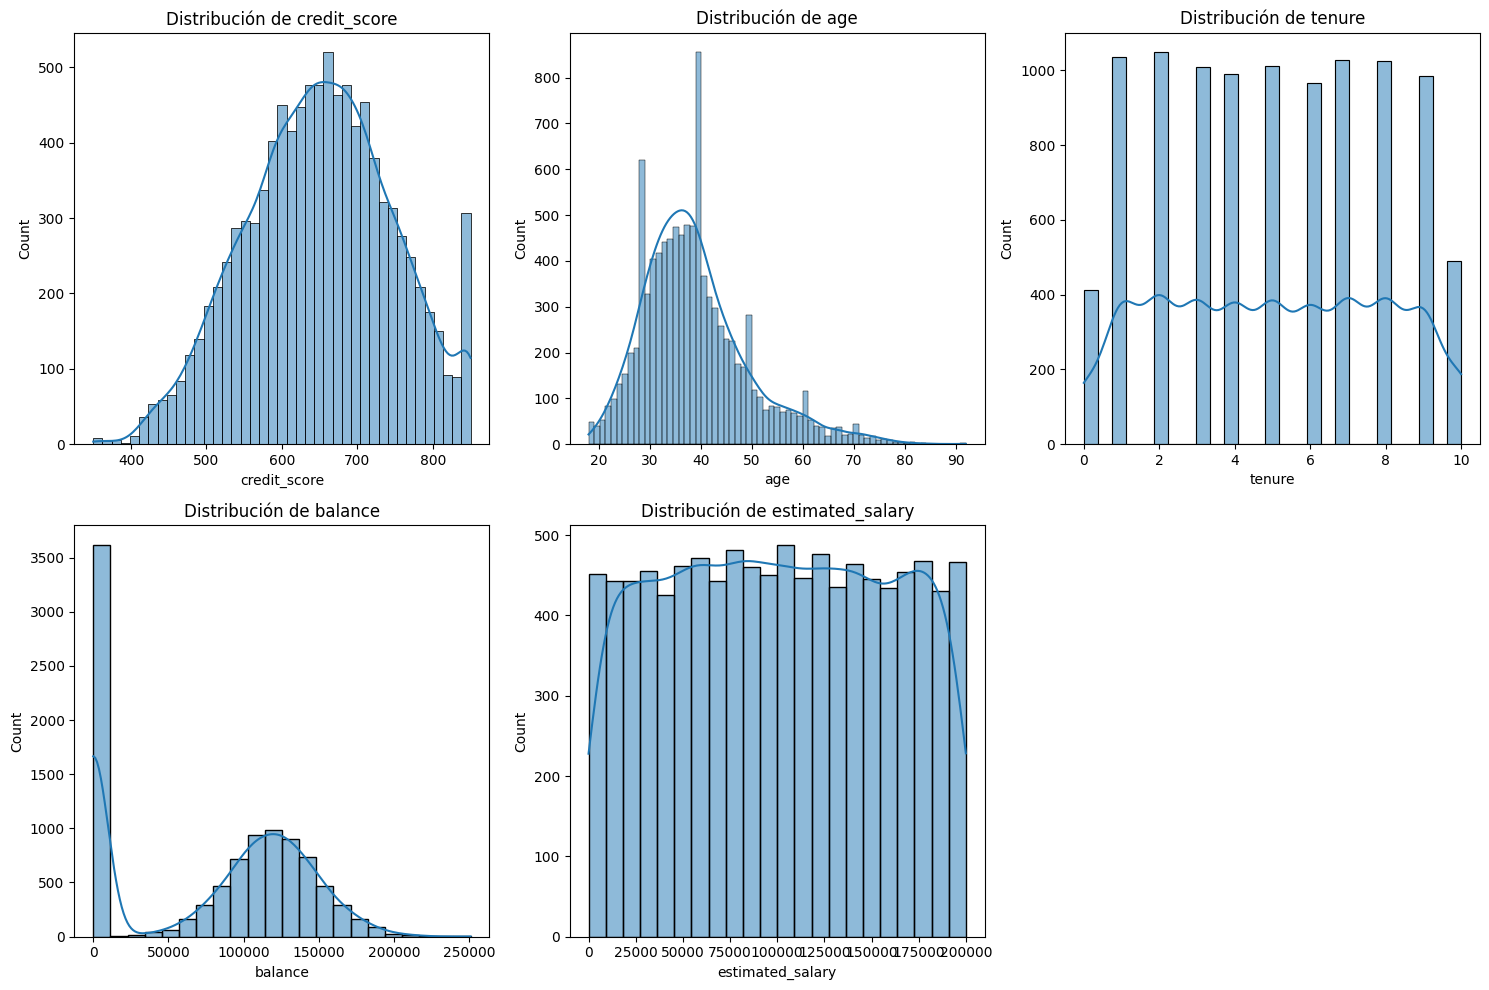


=== Univariado: categóricas, discretas y target ===

Distribución de 'country' (%):
country
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64

Distribución de 'gender' (%):
gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64

Distribución de 'products_number' (%):
products_number
1    50.84
2    45.90
3     2.66
4     0.60
Name: proportion, dtype: float64

Distribución de 'credit_card' (%):
credit_card
1    70.55
0    29.45
Name: proportion, dtype: float64

Distribución de 'active_member' (%):
active_member
1    51.51
0    48.49
Name: proportion, dtype: float64

Distribución de 'churn' (%):
churn
0    79.63
1    20.37
Name: proportion, dtype: float64


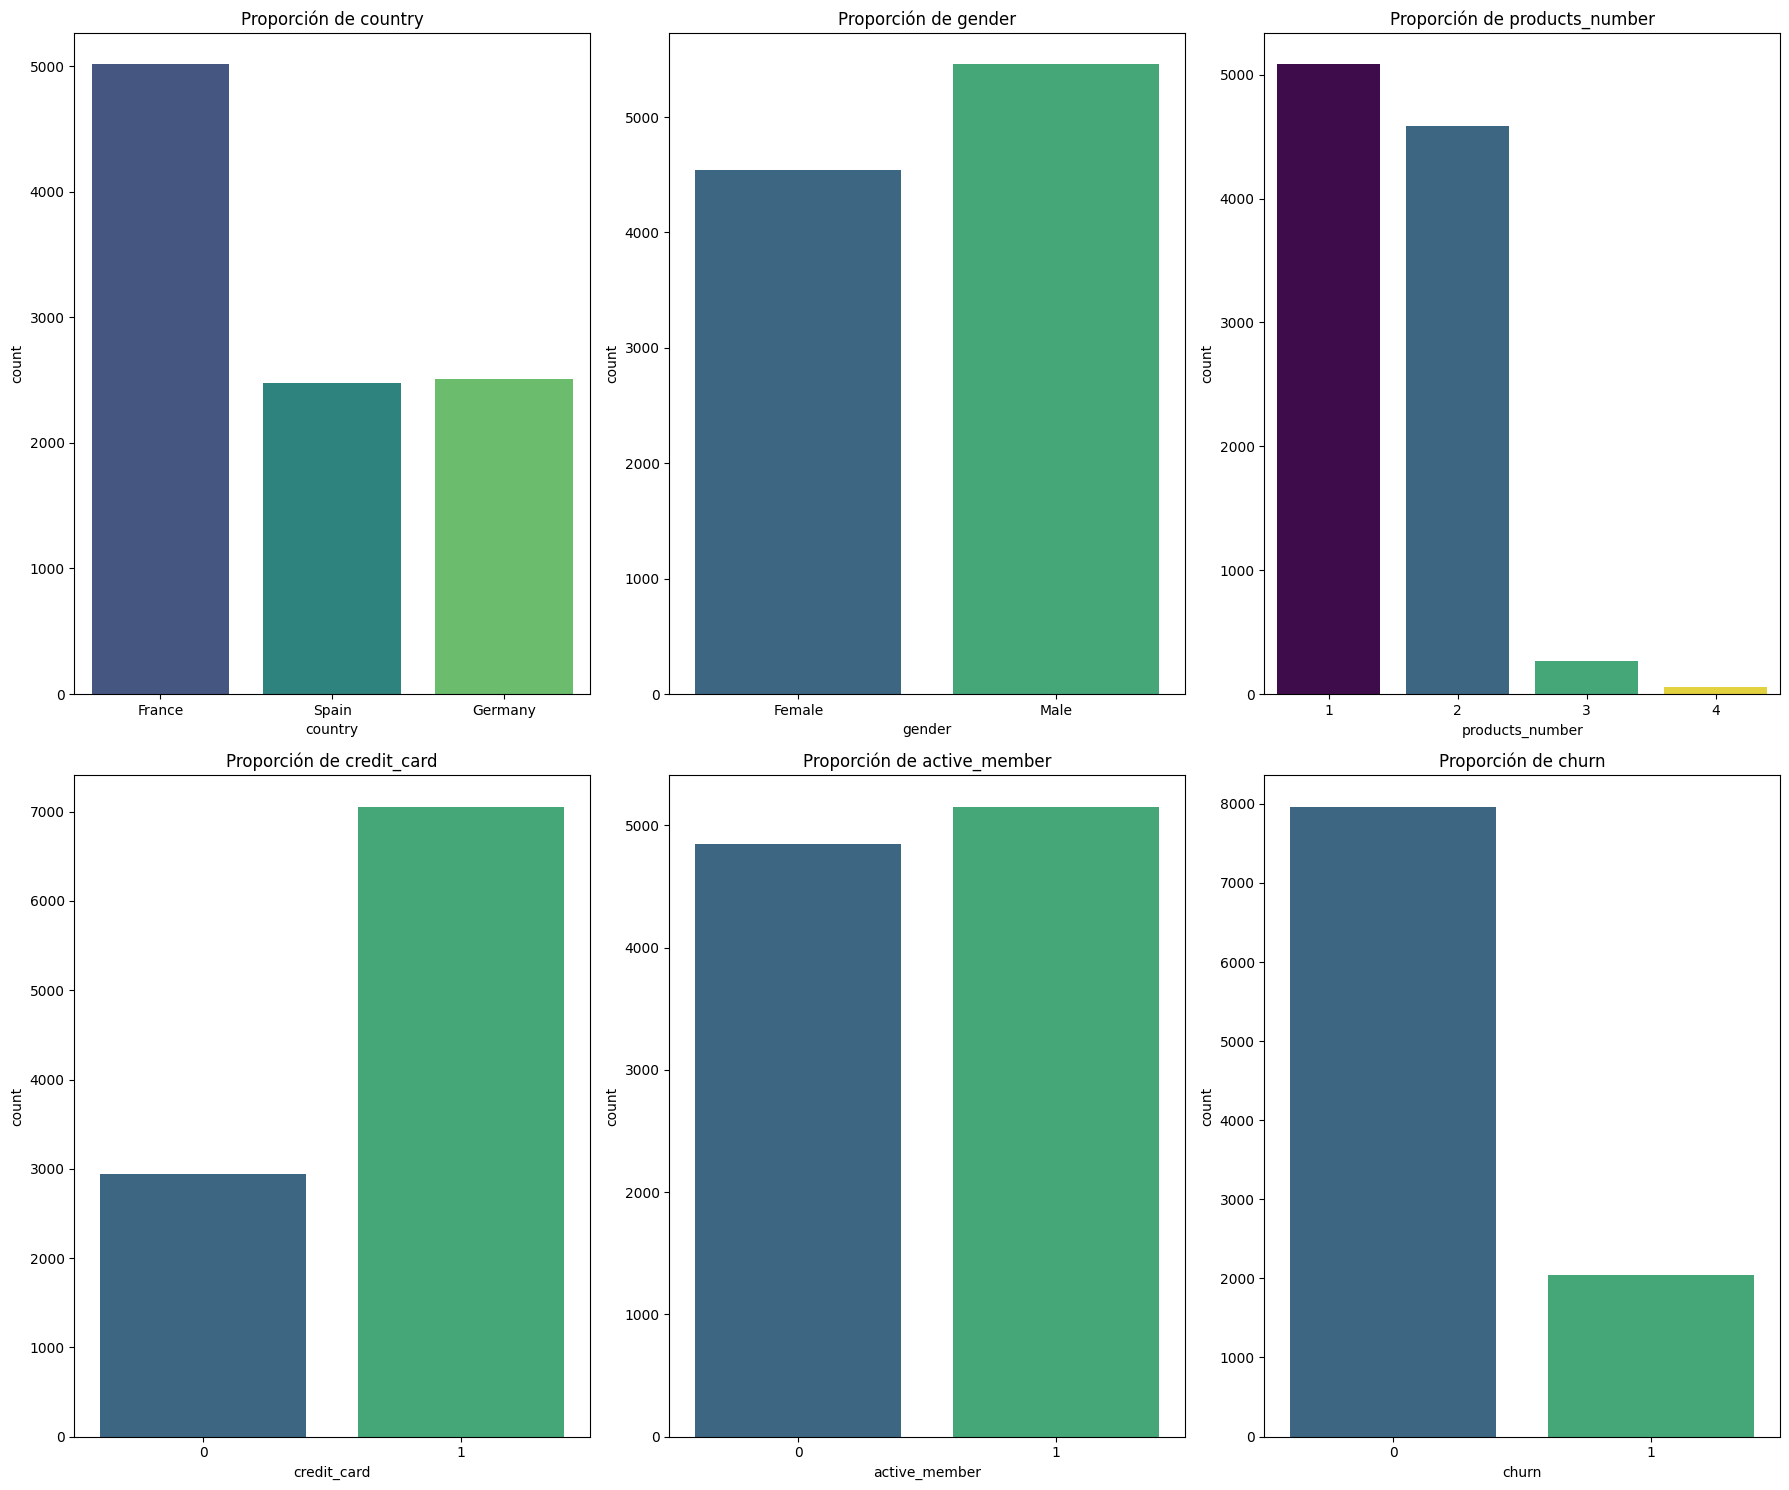


>>> Tasa de churn global: 20.37% (2037 de 10000 clientes). Esto representa un desbalance de clases (~5:1) que deberá abordarse en la etapa de preparación de datos (sección 3).

=== Bivariado: numéricas vs. churn (medias) ===
       credit_score   age  tenure  balance  estimated_salary
churn                                                       
0             651.9  37.4     5.0  72745.3           99738.4
1             645.4  44.8     4.9  91108.5          101465.7


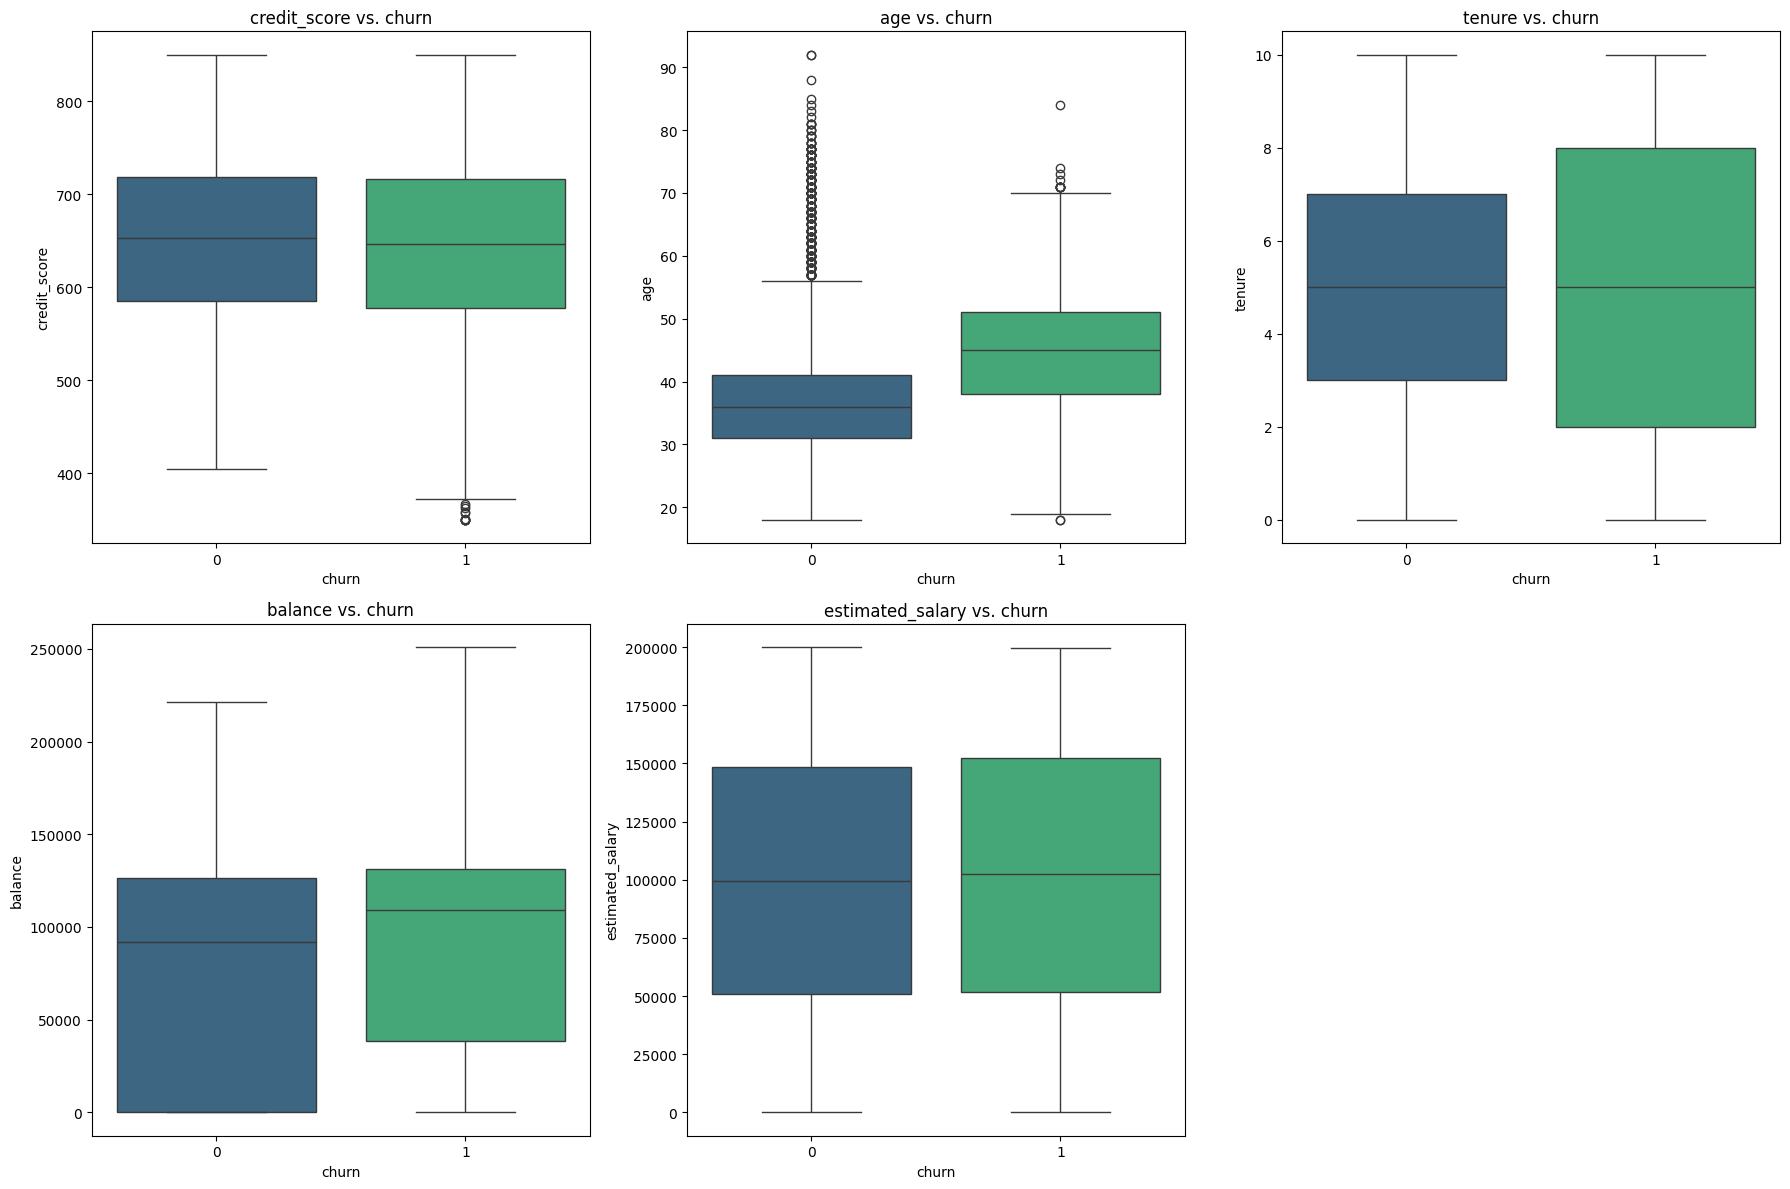


=== Bivariado: categóricas/discretas vs. churn (tasa de churn por grupo) ===

Tasa de churn por 'country' (%):
country
France     16.15
Germany    32.44
Spain      16.67
Name: churn, dtype: float64

Tasa de churn por 'gender' (%):
gender
Female    25.07
Male      16.46
Name: churn, dtype: float64

Tasa de churn por 'products_number' (%):
products_number
1     27.71
2      7.58
3     82.71
4    100.00
Name: churn, dtype: float64

Tasa de churn por 'credit_card' (%):
credit_card
0    20.81
1    20.18
Name: churn, dtype: float64

Tasa de churn por 'active_member' (%):
active_member
0    26.85
1    14.27
Name: churn, dtype: float64


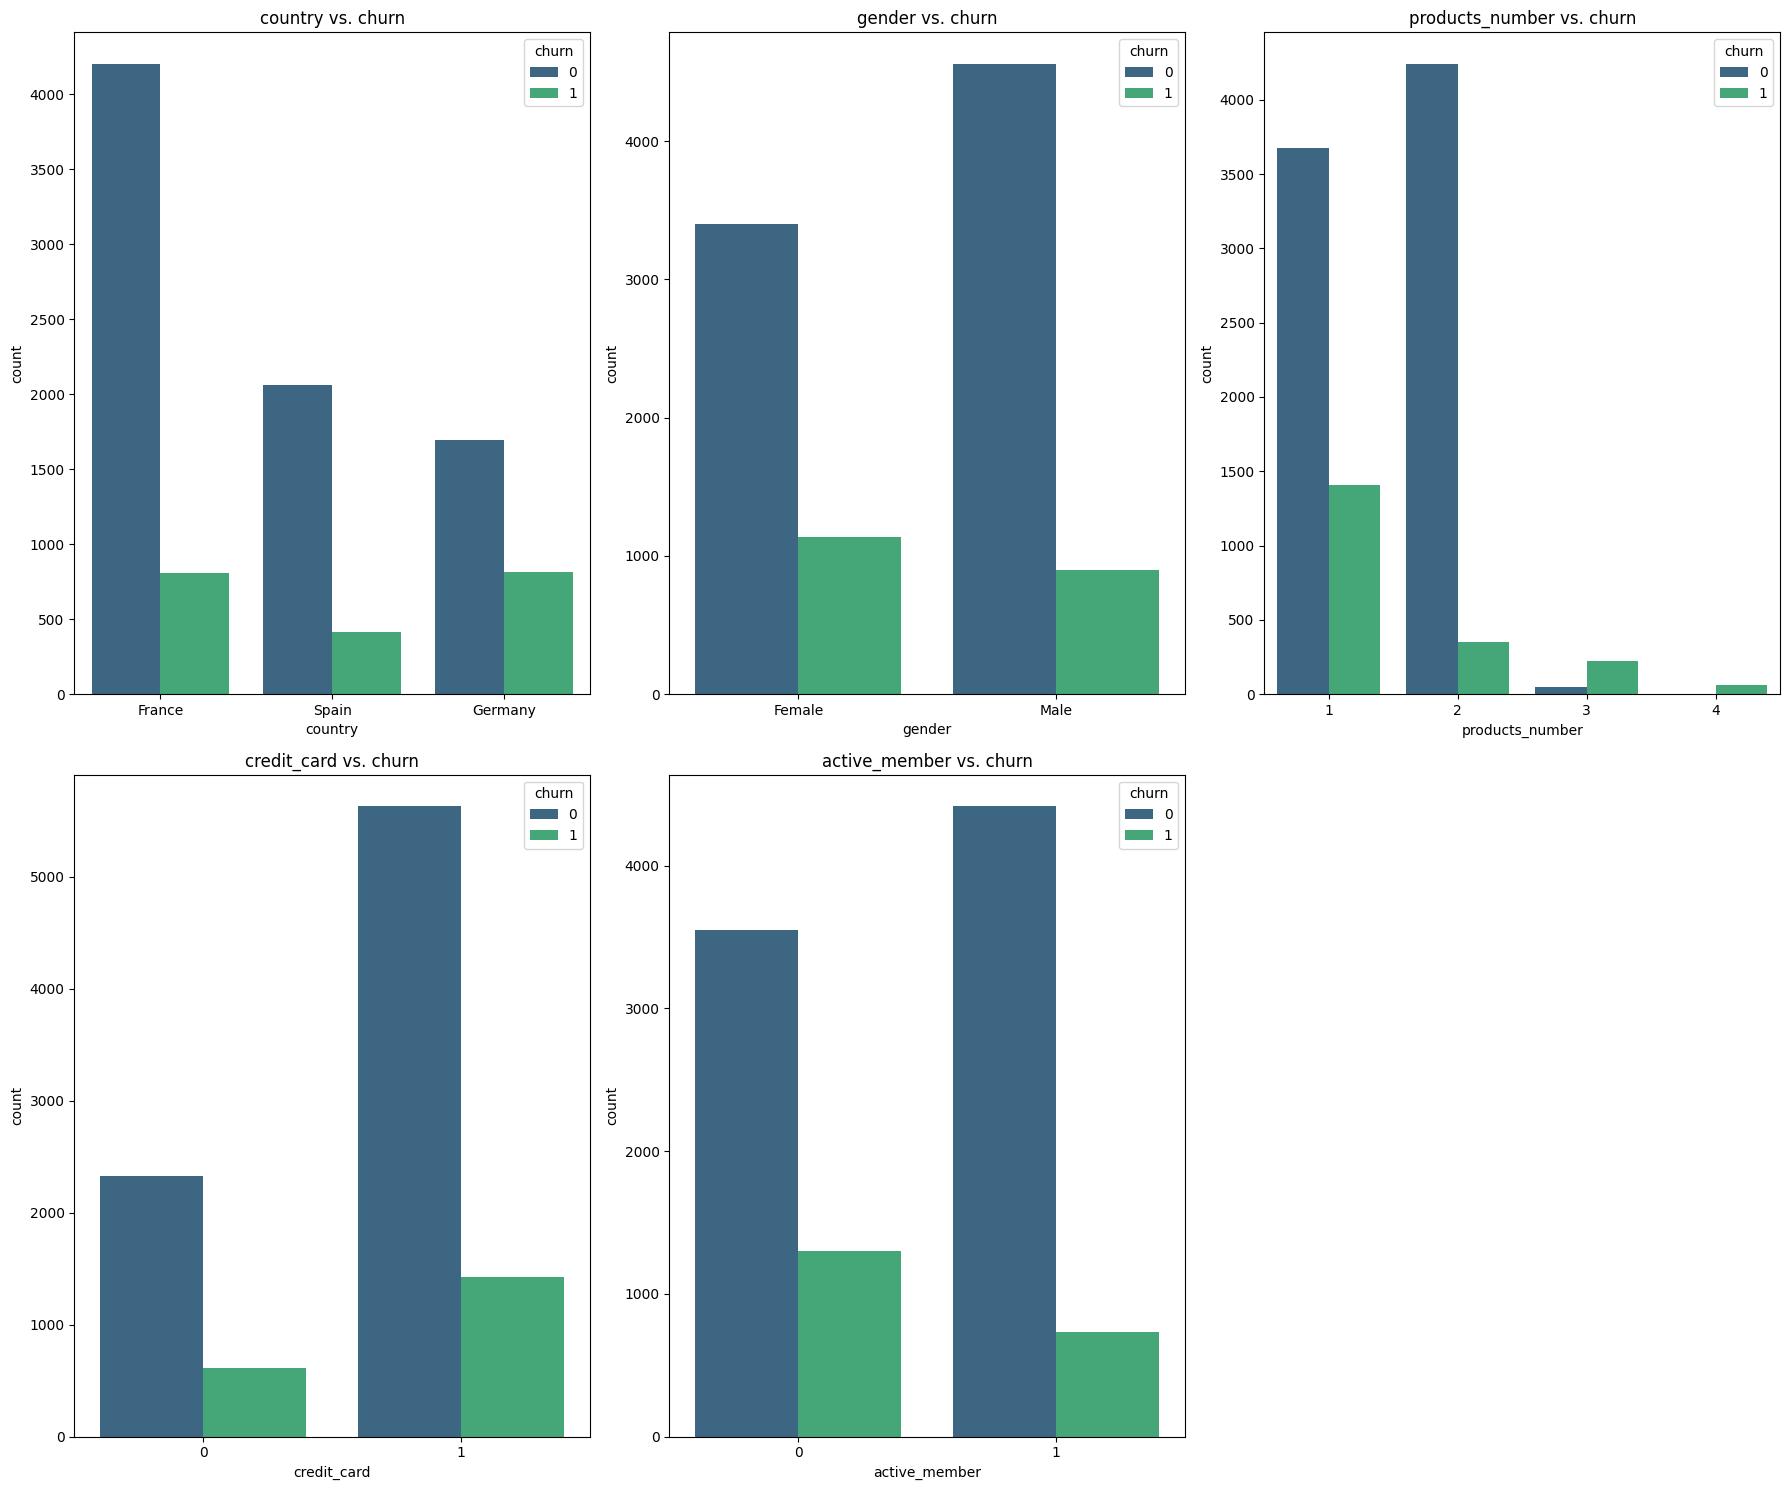


=== Detección de outliers: IQR ===

Columna 'credit_score':
  - N° outliers (IQR): 15
  - % outliers: 0.15%
  - Límites: [383.00, 919.00]

Columna 'age':
  - N° outliers (IQR): 359
  - % outliers: 3.59%
  - Límites: [14.00, 62.00]

Columna 'tenure':
  - N° outliers (IQR): 0
  - % outliers: 0.00%
  - Límites: [-3.00, 13.00]

Columna 'balance':
  - N° outliers (IQR): 0
  - % outliers: 0.00%
  - Límites: [-191466.36, 319110.60]

Columna 'estimated_salary':
  - N° outliers (IQR): 0
  - % outliers: 0.00%
  - Límites: [-96577.10, 296967.45]

=== Comparación con z-score (|z| > 3) ===
  - credit_score: 8 outliers por z-score (vs. 15 por IQR)
  - age: 133 outliers por z-score (vs. 359 por IQR)
  - tenure: 0 outliers por z-score (vs. 0 por IQR)
  - balance: 0 outliers por z-score (vs. 0 por IQR)
  - estimated_salary: 0 outliers por z-score (vs. 0 por IQR)

=== Análisis de valores faltantes ===
  - No se encontraron valores faltantes en ninguna columna del dataset.

=== Decisiones y Justificacio

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats

# df ya cargado desde la celda anterior

# =========================================================
# 1. DESCRIPCIÓN GENERAL DEL DATASET
# =========================================================
print("=== Descripción general del dataset ===")
print(df.info())
print("\nValores duplicados (filas completas):", df.duplicated().sum())
print("Valores duplicados (sin customer_id):", df.drop(columns=['customer_id']).duplicated().sum())
print("\nValores faltantes por columna:")
print(df.isnull().sum())

continuous_numerical_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']
discrete_numerical_cols = ['products_number', 'credit_card', 'active_member']
categorical_cols = ['country', 'gender']
target_col = 'churn'

# =========================================================
# 2. ANÁLISIS UNIVARIADO
# =========================================================
print("\n=== Univariado: numéricas continuas ===")
print(df[continuous_numerical_cols].describe())

plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

print("\n=== Univariado: categóricas, discretas y target ===")
all_categorical_for_counts = categorical_cols + discrete_numerical_cols + [target_col]

plt.figure(figsize=(18, 15))
num_plots = len(all_categorical_for_counts)
rows = (num_plots + 2) // 3

for i, col in enumerate(all_categorical_for_counts):
    plt.subplot(rows, 3, i + 1)
    print(f"\nDistribución de '{col}' (%):")
    print((df[col].value_counts(normalize=True) * 100).round(2))
    sns.countplot(x=col, data=df, hue=col, palette='viridis', legend=False)
    plt.title(f'Proporción de {col}')
plt.tight_layout()
plt.show()

# Nota clave de negocio: el target está desbalanceado.
churn_rate = df['churn'].mean() * 100
print(f"\n>>> Tasa de churn global: {churn_rate:.2f}% "
      f"({df['churn'].sum()} de {len(df)} clientes). "
      f"Esto representa un desbalance de clases (~{round(100/churn_rate)}:1) "
      f"que deberá abordarse en la etapa de preparación de datos (sección 3).")

# =========================================================
# 3. ANÁLISIS BIVARIADO (predictores vs. churn)
# =========================================================
print("\n=== Bivariado: numéricas vs. churn (medias) ===")
print(df.groupby('churn')[continuous_numerical_cols].mean().round(1))

plt.figure(figsize=(18, 12))
for i, col in enumerate(continuous_numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=target_col, y=col, hue=target_col, data=df, palette='viridis', legend=False)
    plt.title(f'{col} vs. {target_col}')
plt.tight_layout()
plt.show()

print("\n=== Bivariado: categóricas/discretas vs. churn (tasa de churn por grupo) ===")
for col in categorical_cols + discrete_numerical_cols:
    print(f"\nTasa de churn por '{col}' (%):")
    print((df.groupby(col)['churn'].mean() * 100).round(2))

plt.figure(figsize=(18, 15))
num_biv_plots = len(categorical_cols + discrete_numerical_cols)
biv_rows = (num_biv_plots + 2) // 3

for i, col in enumerate(categorical_cols + discrete_numerical_cols):
    plt.subplot(biv_rows, 3, i + 1)
    sns.countplot(x=col, hue=target_col, data=df, palette='viridis')
    plt.title(f'{col} vs. {target_col}')
plt.tight_layout()
plt.show()

# =========================================================
# 4. DETECCIÓN DE VALORES ATÍPICOS (IQR y z-score)
# =========================================================
print("\n=== Detección de outliers: IQR ===")
outlier_summary = {}
for col in continuous_numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = {
        'num_outliers': len(outliers),
        'percentage': len(outliers) / len(df) * 100,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }
    print(f"\nColumna '{col}':")
    print(f"  - N° outliers (IQR): {outlier_summary[col]['num_outliers']}")
    print(f"  - % outliers: {outlier_summary[col]['percentage']:.2f}%")
    print(f"  - Límites: [{lower_bound:.2f}, {upper_bound:.2f}]")

print("\n=== Comparación con z-score (|z| > 3) ===")
for col in continuous_numerical_cols:
    z = stats.zscore(df[col])
    n_out_z = (abs(z) > 3).sum()
    print(f"  - {col}: {n_out_z} outliers por z-score "
          f"(vs. {outlier_summary[col]['num_outliers']} por IQR)")

# =========================================================
# 5. ANÁLISIS DE VALORES FALTANTES
# =========================================================
print("\n=== Análisis de valores faltantes ===")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
if missing_values.empty:
    print("  - No se encontraron valores faltantes en ninguna columna del dataset.")
else:
    print("  - Columnas con valores faltantes:")
    print(missing_values)
    print("  - Hipótesis sobre posibles causas: revisar si el faltante se concentra en "
          "algún país, canal de adquisición o rango de fechas, lo cual sugeriría un problema "
          "de captura de datos en ese segmento específico, en lugar de aleatoriedad pura.")

# =========================================================
# DECISIONES Y JUSTIFICACIONES
# =========================================================
print("\n=== Decisiones y Justificaciones ===")

print("\n--- Tratamiento de valores atípicos ---")
print("Se identificaron outliers relevantes solo en 'credit_score' (~0.15% de los casos) "
      "y 'age' (~3.6% por IQR). Las variables 'tenure', 'balance' y 'estimated_salary' "
      "no presentan outliers bajo este criterio, ya que son variables con topes naturales "
      "del negocio (años de relación, saldo, salario). "
      "Para 'age' y 'credit_score' se aplicará winsorización (recorte a los límites de IQR) "
      "en lugar de eliminación, dado que los valores extremos corresponden a clientes reales "
      "(p. ej., clientes de mayor edad) y no a errores de captura; eliminarlos significaría "
      "perder información válida sobre un segmento que, como se vio en el análisis bivariado, "
      "tiene mayor propensión al churn.")

print("\n--- Imputación de datos faltantes ---")
if missing_values.empty:
    print("El dataset no presenta valores faltantes en ninguna columna, por lo que no se "
          "requiere ninguna estrategia de imputación en esta etapa.")
else:
    print("Se imputará usando mediana para variables numéricas (robusta a outliers) y "
          "moda para variables categóricas.")

print("\n--- Variables a eliminar o transformar ---")
print("- 'customer_id': se elimina, es solo un identificador sin valor predictivo.")
print("- 'country' y 'gender': requieren One-Hot Encoding para el modelado.")
print("- 'products_number' merece atención especial: la relación con churn es fuertemente "
      "no lineal (7.6% de churn con 2 productos vs. 82.7% con 3 y 100% con 4 productos). "
      "Esto sugiere que podría tratarse como variable categórica en lugar de numérica "
      "continua, o crear una variable binaria 'tiene_3_o_mas_productos' como señal de "
      "alerta temprana.")
print("- Variables con mayor relación aparente con el churn, a confirmar en el modelado: "
      "'products_number', 'country' (especialmente Germany), 'age' y 'active_member'.")



### 3. Preparación de los Datos

- Codifique las variables categóricas (p.ej., *One-Hot Encoding*).
- Escale las variables numéricas cuando sea necesario.
- Divida los datos en conjuntos de entrenamiento y prueba utilizando **estratificación**.
- Evalúe si existe **desbalance de clases** y cómo lo abordará (p.ej., SMOTE, pesos de clase).



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

print("=== Preparación de Datos ===")

# -------------------------------------------------------------------
# 0. Copia de trabajo y eliminación de customer_id
# -------------------------------------------------------------------
df_processed = df.copy()
df_processed = df_processed.drop('customer_id', axis=1)

X = df_processed.drop('churn', axis=1)
y = df_processed['churn']

# -------------------------------------------------------------------
# 1. Definición de tipos de variable (alineado con el EDA)
# -------------------------------------------------------------------
# Solo las variables verdaderamente continuas se escalan.
# 'products_number', 'credit_card' y 'active_member' se dejan en su escala
# original: son discretas/binarias y escalarlas dificulta la interpretación
# de los coeficientes en la Regresión Logística (sección 4.1).
continuous_features = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']
categorical_features = ['country', 'gender']
# products_number, credit_card y active_member pasan sin transformar (remainder='passthrough')

# -------------------------------------------------------------------
# 2. Tratamiento de outliers (winsorización) en credit_score y age
#    usando los límites de IQR calculados en el EDA (sección 2)
# -------------------------------------------------------------------
credit_score_lower = outlier_summary['credit_score']['lower_bound']
credit_score_upper = outlier_summary['credit_score']['upper_bound']
age_lower = outlier_summary['age']['lower_bound']
age_upper = outlier_summary['age']['upper_bound']

X['credit_score'] = np.clip(X['credit_score'], credit_score_lower, credit_score_upper)
X['age'] = np.clip(X['age'], age_lower, age_upper)
print("Winsorización aplicada a 'credit_score' y 'age' según límites IQR del EDA.")

# -------------------------------------------------------------------
# 3. Split train/test ESTRATIFICADO, antes de escalar/encodear/SMOTE
#    (evita data leakage: el test no debe influir en ningún ajuste)
# -------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nDatos divididos: {len(X_train)} train / {len(X_test)} test.")
print(f"Proporción de churn en train: {y_train.mean():.4f}")
print(f"Proporción de churn en test:  {y_test.mean():.4f}")

# -------------------------------------------------------------------
# 4. Preprocesamiento: One-Hot Encoding (categóricas) + Escalado (continuas)
#    drop='first' evita la trampa de variables dummy (multicolinealidad)
# -------------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'  # deja products_number, credit_card, active_member sin tocar
)

X_train_processed = preprocessor.fit_transform(X_train)   # fit SOLO en train
X_test_processed = preprocessor.transform(X_test)          # test solo se transforma

# Reconstrucción de nombres de columnas en el orden real de salida
ohe_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
passthrough_names = [c for c in X_train.columns
                      if c not in continuous_features and c not in categorical_features]
all_feature_names = continuous_features + ohe_names + passthrough_names

X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

print(f"\nDimensiones tras preprocesar -> train: {X_train_processed_df.shape}, "
      f"test: {X_test_processed_df.shape}")
print("Columnas finales:", all_feature_names)

# Chequeo rápido: las discretas deben conservar su escala original
print("\nVerificación: 'products_number' conserva valores 1-4 (no escalada):")
print(X_train_processed_df['products_number'].value_counts().sort_index())

# -------------------------------------------------------------------
# 5. Desbalance de clases: comparamos dos estrategias
# -------------------------------------------------------------------
print("\n=== Desbalance de clases ===")
print(f"Distribución original en train:\n{y_train.value_counts()}")
print(f"({y_train.mean()*100:.1f}% churn vs. {(1-y_train.mean())*100:.1f}% no-churn "
      f"-> desbalance de aprox. {round((1-y_train.mean())/y_train.mean())}:1)")

# --- Estrategia A: class_weight (no altera los datos, ajusta la función de pérdida) ---
class_weights = compute_class_weight(
    class_weight='balanced', classes=np.array([0, 1]), y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"\nEstrategia A - class_weight='balanced': {class_weight_dict}")
print(f"  -> cada error en churn=1 pesa ~{class_weights[1]/class_weights[0]:.2f}x más "
      f"que un error en churn=0 durante el entrenamiento.")

# --- Estrategia B: SMOTE (genera ejemplos sintéticos de la clase minoritaria) ---
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed_df, y_train)
print(f"\nEstrategia B - SMOTE:")
print(f"  Antes:   {y_train.value_counts().to_dict()}")
print(f"  Después: {y_train_smote.value_counts().to_dict()}")

print("\n--- Decisión y justificación ---")
print("Se usará 'class_weight=balanced' como estrategia principal para Regresión "
      "Logística, Árbol de Decisión y Random Forest (todos lo soportan nativamente "
      "vía el parámetro class_weight), ya que no infla artificialmente el tamaño del "
      "dataset ni genera observaciones sintéticas que podrían no representar clientes "
      "reales. SMOTE se deja como estrategia alternativa para comparar en la sección 5, "
      "particularmente útil para Gradient Boosting si su implementación no soporta "
      "class_weight de forma directa. Es clave aplicar SMOTE únicamente sobre el "
      "conjunto de entrenamiento (X_train_smote, y_train_smote): el conjunto de test "
      "(X_test_processed_df, y_test) se mantiene con la distribución real para que la "
      "evaluación refleje el escenario real del banco.")

# Variables que quedan disponibles para el modelado (sección 4):
#   X_train_processed_df, y_train              -> train sin balancear (usar con class_weight)
#   X_train_smote, y_train_smote                -> train balanceado con SMOTE
#   X_test_processed_df, y_test                  -> test (SIEMPRE con distribución real)
#   class_weight_dict                            -> para pasar a los modelos

=== Preparación de Datos ===
Winsorización aplicada a 'credit_score' y 'age' según límites IQR del EDA.

Datos divididos: 8000 train / 2000 test.
Proporción de churn en train: 0.2037
Proporción de churn en test:  0.2035

Dimensiones tras preprocesar -> train: (8000, 11), test: (2000, 11)
Columnas finales: ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary', 'country_Germany', 'country_Spain', 'gender_Male', 'products_number', 'credit_card', 'active_member']

Verificación: 'products_number' conserva valores 1-4 (no escalada):
products_number
1.0    4071
2.0    3672
3.0     207
4.0      50
Name: count, dtype: int64

=== Desbalance de clases ===
Distribución original en train:
churn
0    6370
1    1630
Name: count, dtype: int64
(20.4% churn vs. 79.6% no-churn -> desbalance de aprox. 4:1)

Estrategia A - class_weight='balanced': {0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}
  -> cada error en churn=1 pesa ~3.91x más que un error en churn=0 durante el en



### 4. Fase de Modelado

Deberá construir **cuatro modelos de clasificación**:

#### 4.1 Regresión Logística
- Utilícela como **modelo de referencia (*baseline*)**.
- Explique los coeficientes e interprételos en términos de probabilidad de *churn*.

#### 4.2 Árbol de Decisión
- Realice ajuste de hiperparámetros (p.ej., `max_depth`, `min_samples_split`, `min_samples_leaf`).

#### 4.3 Random Forest
- Utilice búsqueda aleatoria o exhaustiva de hiperparámetros (p.ej., número de árboles, profundidad, tamaño de hoja).

#### 4.4 Gradient Boosting
- Ajuste la tasa de aprendizaje, la profundidad y el número de estimadores.
- Argumente por qué el *boosting* podría superar a los demás modelos.



In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

print("=== 4. Fase de Modelado ===")

# Diccionario donde se guardará cada modelo entrenado y su información,
# para reutilizar en la sección 5 (Evaluación de Modelos).
models = {}

# -------------------------------------------------------------------
# 4.1 REGRESIÓN LOGÍSTICA — modelo de referencia (baseline)
# -------------------------------------------------------------------
print("\n--- 4.1 Regresión Logística (baseline) ---")
start_time = time.time()

log_reg = LogisticRegression(
    random_state=42,
    solver='liblinear',          # estable para datasets de este tamaño
    class_weight=class_weight_dict,  # corrige el desbalance ~4:1 sin alterar los datos
    max_iter=1000
)
log_reg.fit(X_train_processed_df, y_train)

elapsed = time.time() - start_time
print(f"Tiempo de entrenamiento: {elapsed:.3f} segundos")

models['Logistic Regression'] = {
    'best_model': log_reg,
    'X_test': X_test_processed_df,
    'training_time': elapsed
}

# Interpretación de coeficientes en términos de Odds Ratio (probabilidad de churn)
print("\nInterpretación de coeficientes:")
feature_names = X_train_processed_df.columns
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_reg.coef_[0]
})
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Odds_Ratio', ascending=False).reset_index(drop=True)
print(coef_df)

print("\nCómo leer la tabla: un Odds Ratio > 1 indica que, manteniendo las demás variables "
      "constantes, un aumento de una unidad en esa variable incrementa las odds de churn "
      "(se multiplican por el Odds Ratio). Un Odds Ratio < 1 indica el efecto contrario.")

# El ejemplo se construye dinámicamente a partir del coeficiente más fuerte real,
# en vez de usar un número fijo de ejemplo.
top_feature = coef_df.iloc[0]
print(f"\nPor ejemplo, '{top_feature['Feature']}' tiene un Odds Ratio de "
      f"{top_feature['Odds_Ratio']:.2f}: manteniendo las demás variables constantes, "
      f"un incremento de una unidad en esta variable multiplica las odds de churn por "
      f"{top_feature['Odds_Ratio']:.2f} (un cambio de {(top_feature['Odds_Ratio']-1)*100:+.1f}% "
      f"en las odds).")

# Nota sobre 'products_number': su relación con el churn es fuertemente NO lineal
# (vista en el EDA: ~8% de churn con 2 productos, ~83% con 3, 100% con 4). La
# Regresión Logística asume linealidad en el log-odds, por lo que puede arrojar un
# coeficiente que no refleja ese quiebre abrupto. Esta limitación motiva probar
# modelos no lineales en las siguientes subsecciones.
if 'products_number' in coef_df['Feature'].values:
    pn = coef_df[coef_df['Feature'] == 'products_number'].iloc[0]
    print(f"\nNota: 'products_number' obtiene un Odds Ratio de {pn['Odds_Ratio']:.2f} en este "
          f"modelo lineal. El EDA bivariado mostró una relación marcadamente no lineal con el "
          f"churn (salto abrupto desde 2 a 3+ productos), que la Regresión Logística no puede "
          f"capturar al asumir una relación lineal con el log-odds. Esta es una de las "
          f"motivaciones centrales para evaluar Árbol de Decisión, Random Forest y Gradient "
          f"Boosting, que sí pueden modelar relaciones no lineales y umbrales.")

# -------------------------------------------------------------------
# 4.2 ÁRBOL DE DECISIÓN — con ajuste de hiperparámetros
# -------------------------------------------------------------------
print("\n\n--- 4.2 Árbol de Decisión ---")
start_time = time.time()

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

dt_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42, class_weight=class_weight_dict),
    param_grid=dt_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
dt_search.fit(X_train_processed_df, y_train)

elapsed = time.time() - start_time
print(f"Tiempo de entrenamiento (incluye búsqueda de hiperparámetros): {elapsed:.2f} segundos")
print(f"Mejores hiperparámetros: {dt_search.best_params_}")
print(f"Mejor ROC-AUC en validación cruzada: {dt_search.best_score_:.4f}")

models['Decision Tree'] = {
    'best_model': dt_search.best_estimator_,
    'X_test': X_test_processed_df,
    'training_time': elapsed,
    'best_params': dt_search.best_params_
}

# -------------------------------------------------------------------
# 4.3 RANDOM FOREST — con búsqueda aleatoria de hiperparámetros
# -------------------------------------------------------------------
print("\n\n--- 4.3 Random Forest ---")
start_time = time.time()

rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight=class_weight_dict),
    param_distributions=rf_param_dist,
    n_iter=20,          # número de combinaciones aleatorias a probar
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train_processed_df, y_train)

elapsed = time.time() - start_time
print(f"Tiempo de entrenamiento (incluye búsqueda de hiperparámetros): {elapsed:.2f} segundos")
print(f"Mejores hiperparámetros: {rf_search.best_params_}")
print(f"Mejor ROC-AUC en validación cruzada: {rf_search.best_score_:.4f}")

models['Random Forest'] = {
    'best_model': rf_search.best_estimator_,
    'X_test': X_test_processed_df,
    'training_time': elapsed,
    'best_params': rf_search.best_params_
}

# -------------------------------------------------------------------
# 4.4 GRADIENT BOOSTING — ajuste de learning_rate, profundidad, n_estimators
# -------------------------------------------------------------------
print("\n\n--- 4.4 Gradient Boosting ---")
print("Nota: GradientBoostingClassifier de scikit-learn no admite el parámetro "
      "'class_weight'. Por eso, para este modelo se aborda el desbalance con SMOTE. "
      "IMPORTANTE: SMOTE no se aplica antes de la búsqueda de hiperparámetros (eso "
      "generaría data leakage, ya que ejemplos sintéticos quedarían repartidos entre "
      "los folds de entrenamiento y validación, inflando artificialmente el AUC de "
      "validación cruzada). En su lugar, se usa un Pipeline de imblearn que aplica "
      "SMOTE de nuevo en cada fold, solo sobre los datos de entrenamiento de ese fold. "
      "La evaluación final, en cualquier caso, se realiza siempre sobre el conjunto de "
      "test original (X_test_processed_df / y_test), que conserva la distribución real "
      "de churn del banco, para que la comparación con los demás modelos sea justa.")

start_time = time.time()

gb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42))
])

gb_param_grid = {
    'gb__n_estimators': [100, 200, 300],
    'gb__learning_rate': [0.01, 0.05, 0.1],
    'gb__max_depth': [3, 5, 7]
}

gb_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
# Se entrena sobre X_train_processed_df / y_train (SIN balancear de antemano):
# el SMOTE dentro del pipeline se encarga de balancear cada fold de entrenamiento.
gb_search.fit(X_train_processed_df, y_train)

elapsed = time.time() - start_time
print(f"Tiempo de entrenamiento (incluye búsqueda de hiperparámetros): {elapsed:.2f} segundos")
print(f"Mejores hiperparámetros: {gb_search.best_params_}")
print(f"Mejor ROC-AUC en validación cruzada: {gb_search.best_score_:.4f}")

models['Gradient Boosting'] = {
    'best_model': gb_search.best_estimator_,
    'X_test': X_test_processed_df,
    'training_time': elapsed,
    'best_params': gb_search.best_params_
}

print("\nArgumento: por qué Gradient Boosting podría superar a los demás modelos.")
print("Gradient Boosting construye árboles de forma secuencial, donde cada árbol nuevo "
      "se entrena específicamente para corregir los errores residuales de los árboles "
      "anteriores. A diferencia de Random Forest -que promedia árboles independientes "
      "entrenados en paralelo para reducir varianza-, Boosting reduce sesgo de forma "
      "iterativa y tiende a capturar mejor patrones complejos y relaciones no lineales "
      "sutiles, como la observada en 'products_number' o en la interacción entre "
      "'country' y 'active_member'. Esa capacidad de enfocarse en los casos difíciles "
      "de clasificar suele traducirse en mayor poder predictivo en problemas de churn, "
      "a costa de mayor tiempo de entrenamiento y mayor riesgo de sobreajuste si no se "
      "regula bien la profundidad y la tasa de aprendizaje -razón por la cual ambos "
      "hiperparámetros se incluyeron explícitamente en la búsqueda anterior.")

# -------------------------------------------------------------------
# Resumen rápido de los 4 modelos entrenados (detalle completo en sección 5)
# -------------------------------------------------------------------
print("\n\n=== Resumen rápido (AUC en test, detalle completo en sección 5) ===")
for name, info in models.items():
    proba = info['best_model'].predict_proba(info['X_test'])[:, 1]
    auc = roc_auc_score(y_test, proba)
    print(f"{name:22s} -> ROC-AUC test: {auc:.4f}  |  tiempo: {info['training_time']:.2f}s")

=== 4. Fase de Modelado ===

--- 4.1 Regresión Logística (baseline) ---
Tiempo de entrenamiento: 0.025 segundos

Interpretación de coeficientes:
             Feature  Coefficient  Odds_Ratio
0                age     0.842678    2.322578
1    country_Germany     0.827206    2.286919
2            balance     0.178122    1.194971
3      country_Spain     0.055702    1.057283
4   estimated_salary     0.052064    1.053443
5             tenure    -0.018354    0.981814
6        credit_card    -0.064915    0.937147
7       credit_score    -0.084407    0.919057
8    products_number    -0.095449    0.908965
9        gender_Male    -0.549406    0.577293
10     active_member    -0.887312    0.411761

Cómo leer la tabla: un Odds Ratio > 1 indica que, manteniendo las demás variables constantes, un aumento de una unidad en esa variable incrementa las odds de churn (se multiplican por el Odds Ratio). Un Odds Ratio < 1 indica el efecto contrario.

Por ejemplo, 'age' tiene un Odds Ratio de 2.32: manteni



### 5. Evaluación de Modelos

Evalúe todos los modelos utilizando las siguientes métricas:

- **ROC-AUC** (métrica principal)
- Precisión, Recall y F1-score
- Matriz de confusión

Elabore una **tabla comparativa** que resuma el desempeño de todos los modelos. Discuta cuál modelo tiene mejor rendimiento y por qué.



=== 5. Evaluación de Modelos ===

--- Tabla comparativa de desempeño (ordenada por ROC-AUC) ---
             Modelo  ROC-AUC  Precisión  Recall  F1-score
  Gradient Boosting   0.8683     0.6274  0.6413    0.6343
      Random Forest   0.8643     0.5796  0.6708    0.6219
      Decision Tree   0.8376     0.4585  0.7592    0.5717
Logistic Regression   0.7831     0.3908  0.7125    0.5048


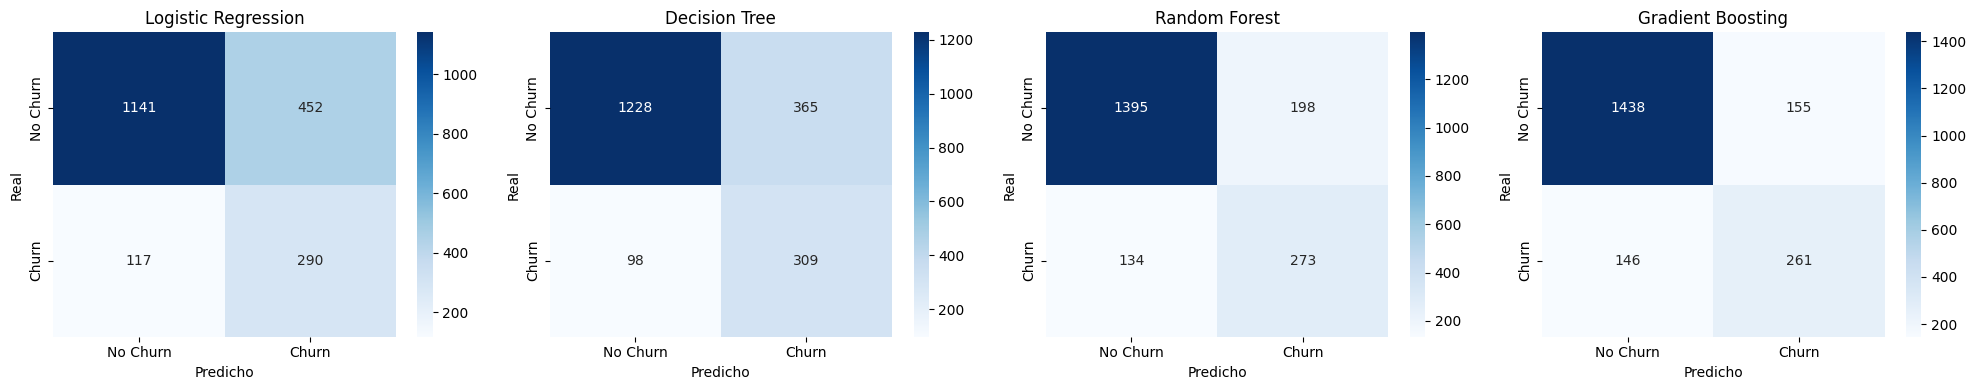

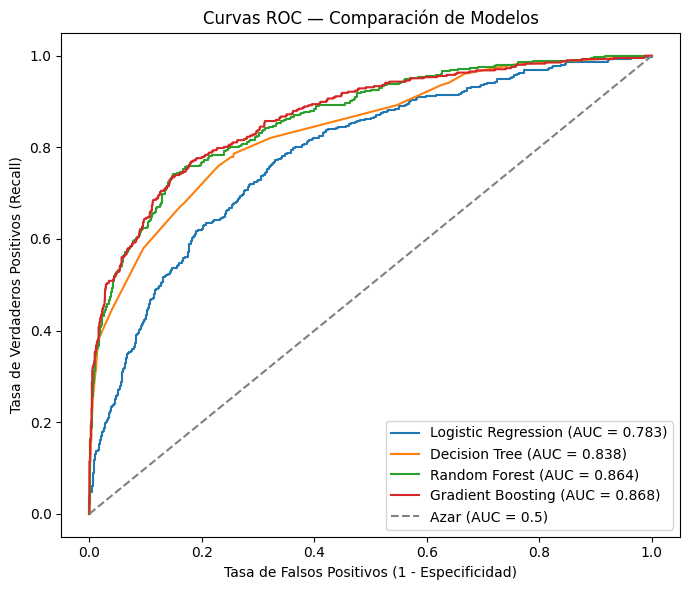


--- Discusión de resultados ---
El modelo con mejor desempeño según ROC-AUC (métrica principal) es 'Gradient Boosting', con un AUC de 0.8683.
Le sigue 'Random Forest' con un AUC de 0.8643 (diferencia de 0.0040).

En términos del resto de métricas, 'Gradient Boosting' obtuvo Precisión=0.627, Recall=0.641 y F1-score=0.634 sobre la clase de interés (churn=1).

Por qué tiende a ganar el modelo seleccionado:
- Si el ganador es un modelo de ensamble (Random Forest o Gradient Boosting), su ventaja suele explicarse porque ambos pueden capturar relaciones NO lineales y umbrales abruptos en los datos -como el quiebre observado en 'products_number' (churn ~8% con 2 productos vs. ~83-100% con 3 o más)-, algo que la Regresión Logística no puede representar al asumir linealidad en el log-odds, y que un Árbol de Decisión individual captura de forma más rígida y propensa a sobreajuste.
- Gradient Boosting, en particular, construye árboles de forma secuencial para corregir los errores de los anteriore

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve
)

print("=== 5. Evaluación de Modelos ===")

# -------------------------------------------------------------------
# Cálculo de métricas para cada modelo entrenado en la sección 4.
# Todos se evalúan sobre el MISMO conjunto de test (X_test_processed_df /
# y_test), que conserva la distribución real de churn del banco. Esto es
# clave para que la comparación sea justa, incluso entre modelos que se
# entrenaron con distintos datos de entrada (ej. Gradient Boosting con SMOTE).
# -------------------------------------------------------------------
results_list = []
predictions = {}  # se guarda para reusar en matrices de confusión y curvas ROC

for name, info in models.items():
    model = info['best_model']
    X_test_model = info.get('X_test', X_test_processed_df)

    y_pred_proba = model.predict_proba(X_test_model)[:, 1]
    y_pred = model.predict(X_test_model)

    auc = roc_auc_score(y_test, y_pred_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    predictions[name] = {'y_pred': y_pred, 'y_pred_proba': y_pred_proba, 'cm': cm}

    results_list.append({
        'Modelo': name,
        'ROC-AUC': auc,
        'Precisión': precision,
        'Recall': recall,
        'F1-score': f1
    })

# -------------------------------------------------------------------
# Tabla comparativa
# -------------------------------------------------------------------
results_df = pd.DataFrame(results_list).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
print("\n--- Tabla comparativa de desempeño (ordenada por ROC-AUC) ---")
print(results_df.round(4).to_string(index=False))

best_model_name = results_df.iloc[0]['Modelo']
best_auc = results_df.iloc[0]['ROC-AUC']

# -------------------------------------------------------------------
# Matrices de confusión (una por modelo)
# -------------------------------------------------------------------
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, pred_info) in zip(axes, predictions.items()):
    sns.heatmap(
        pred_info['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn']
    )
    ax.set_title(name)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Curvas ROC superpuestas (apoyo visual a la métrica principal)
# -------------------------------------------------------------------
plt.figure(figsize=(7, 6))
for name, pred_info in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, pred_info['y_pred_proba'])
    auc_val = results_df.loc[results_df['Modelo'] == name, 'ROC-AUC'].values[0]
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curvas ROC — Comparación de Modelos')
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Discusión: ¿cuál modelo tiene mejor rendimiento y por qué?
# Se construye dinámicamente a partir de los resultados reales, no de
# un texto fijo, para que la conclusión siempre coincida con la tabla.
# -------------------------------------------------------------------
print("\n--- Discusión de resultados ---")
second_model_name = results_df.iloc[1]['Modelo'] if len(results_df) > 1 else None
second_auc = results_df.iloc[1]['ROC-AUC'] if len(results_df) > 1 else None

print(f"El modelo con mejor desempeño según ROC-AUC (métrica principal) es "
      f"'{best_model_name}', con un AUC de {best_auc:.4f}.")

if second_model_name:
    gap = best_auc - second_auc
    print(f"Le sigue '{second_model_name}' con un AUC de {second_auc:.4f} "
          f"(diferencia de {gap:.4f}).")

best_row = results_df.iloc[0]
print(f"\nEn términos del resto de métricas, '{best_model_name}' obtuvo "
      f"Precisión={best_row['Precisión']:.3f}, Recall={best_row['Recall']:.3f} "
      f"y F1-score={best_row['F1-score']:.3f} sobre la clase de interés (churn=1).")

print("\nPor qué tiende a ganar el modelo seleccionado:")
print("- Si el ganador es un modelo de ensamble (Random Forest o Gradient Boosting), "
      "su ventaja suele explicarse porque ambos pueden capturar relaciones NO lineales "
      "y umbrales abruptos en los datos -como el quiebre observado en 'products_number' "
      "(churn ~8% con 2 productos vs. ~83-100% con 3 o más)-, algo que la Regresión "
      "Logística no puede representar al asumir linealidad en el log-odds, y que un "
      "Árbol de Decisión individual captura de forma más rígida y propensa a sobreajuste.")
print("- Gradient Boosting, en particular, construye árboles de forma secuencial "
      "para corregir los errores de los anteriores, lo que normalmente le da ventaja "
      "sobre Random Forest (que promedia árboles independientes) en datasets con señales "
      "fuertes pero minoritarias, como los clientes con 3+ productos o de Alemania.")
print("- La Regresión Logística, al ser el modelo más simple (baseline), normalmente "
      "obtiene el menor AUC de los cuatro, pero sigue siendo valiosa por su "
      "interpretabilidad directa en términos de Odds Ratio (sección 4.1).")

print(f"\nRecomendación: avanzar con '{best_model_name}' como modelo final para la "
      f"sección 6 (selección de umbral) y sección 7 (recomendaciones de negocio), "
      f"dado que combina el mejor poder de discriminación (ROC-AUC) con un balance "
      f"razonable entre Precisión y Recall.")



### 6. Umbral Óptimo y Balance entre Métricas de Negocio

Una vez seleccionado el mejor modelo:

- Determine el **umbral de decisión óptimo** (no necesariamente 0,5).
- Compare el desempeño del modelo bajo distintos umbrales.
- Responda y argumente la siguiente pregunta en términos de negocio:

> **¿Es más importante para ABC Bank maximizar el Recall o la Precisión?**
>
> - **Recall alto** → capturar la mayor cantidad posible de clientes que abandonarán (minimizar clientes perdidos).
> - **Precisión alta** → evitar falsas alarmas y no desperdiciar el presupuesto de retención.



=== 6. Umbral Óptimo y Balance entre Métricas de Negocio ===
Modelo seleccionado: Gradient Boosting

--- Desempeño bajo distintos umbrales ---
 Umbral  Precisión  Recall  F1-score  F2-score
   0.10     0.2668  0.9656    0.4181    0.6337
   0.15     0.3212  0.9312    0.4776    0.6749
   0.20     0.3667  0.8919    0.5197    0.6933
   0.25     0.4155  0.8452    0.5571    0.7003
   0.30     0.4524  0.8059    0.5795    0.6970
   0.35     0.5097  0.7764    0.6154    0.7028
   0.40     0.5483  0.7396    0.6297    0.6913
   0.45     0.5868  0.6978    0.6375    0.6723
   0.50     0.6274  0.6413    0.6343    0.6385
   0.55     0.6488  0.5946    0.6205    0.6047
   0.60     0.6982  0.5627    0.6231    0.5854
   0.65     0.7396  0.5233    0.6129    0.5558
   0.70     0.8095  0.5012    0.6191    0.5426
   0.75     0.8488  0.4275    0.5686    0.4746
   0.80     0.8848  0.3587    0.5105    0.4071
   0.85     0.9435  0.2875    0.4407    0.3339
   0.90     0.9425  0.2015    0.3320    0.2391

Umbral ópt

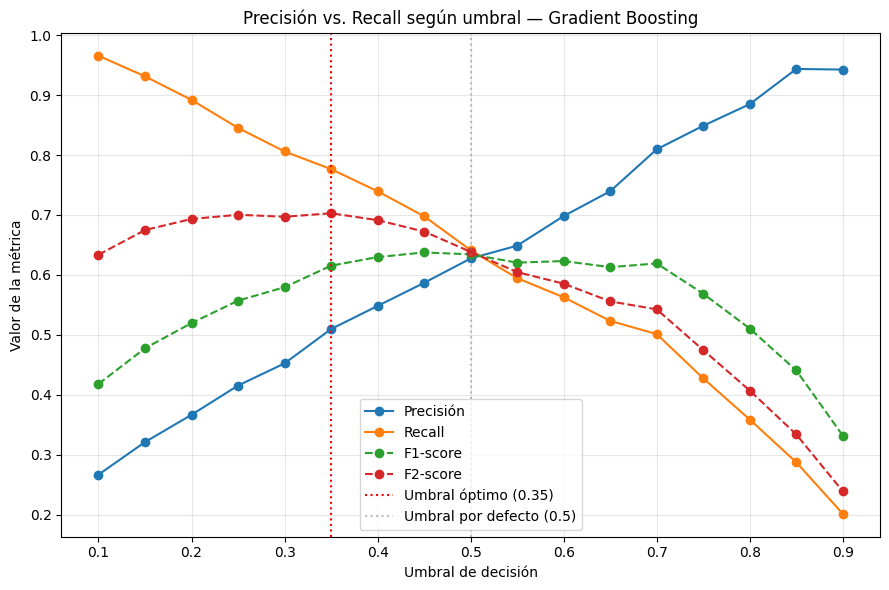

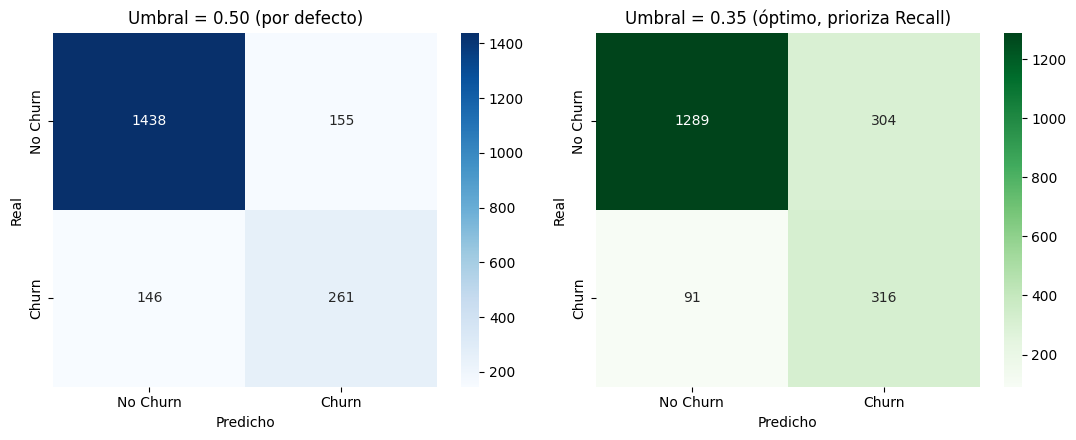


--- Lectura de negocio en el umbral óptimo (0.35) ---
Verdaderos positivos (TP=316): clientes que sí iban a abandonar y el modelo detectó a tiempo -> candidatos reales para una campaña de retención.
Falsos negativos (FN=91): clientes que abandonaron y el modelo NO detectó -> oportunidades de retención perdidas. Es el costo que más le interesa minimizar al banco.
Falsos positivos (FP=304): clientes que el modelo marcó como riesgo pero que en realidad no iban a abandonar -> 'falsas alarmas' que consumen presupuesto de retención (ej. una llamada u oferta de más).
Verdaderos negativos (TN=1289): clientes correctamente identificados como de bajo riesgo, no requieren acción.

--- ¿Es más importante para ABC Bank maximizar el Recall o la Precisión? ---

Para ABC Bank, es más importante priorizar el RECALL por sobre la Precisión,
aunque sin descuidarla por completo. La razón es una asimetría de costos entre
los dos tipos de error:

- Un FALSO NEGATIVO (un cliente que sí abandona y el modelo n

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score, recall_score, f1_score, fbeta_score,
    confusion_matrix, precision_recall_curve
)

print("=== 6. Umbral Óptimo y Balance entre Métricas de Negocio ===")

# -------------------------------------------------------------------
# 0. Se parte del mejor modelo seleccionado en la sección 5
#    (results_df ya viene ordenado por ROC-AUC desde la sección 5)
# -------------------------------------------------------------------
best_model_name = results_df.iloc[0]['Modelo']
best_model = models[best_model_name]['best_model']
X_test_best = models[best_model_name].get('X_test', X_test_processed_df)

print(f"Modelo seleccionado: {best_model_name}")

y_pred_proba = best_model.predict_proba(X_test_best)[:, 1]

# -------------------------------------------------------------------
# 1. Comparación del desempeño bajo distintos umbrales
# -------------------------------------------------------------------
thresholds_to_test = np.arange(0.10, 0.91, 0.05)
threshold_results = []

for t in thresholds_to_test:
    y_pred_t = (y_pred_proba >= t).astype(int)
    precision_t = precision_score(y_test, y_pred_t, zero_division=0)
    recall_t = recall_score(y_test, y_pred_t, zero_division=0)
    f1_t = f1_score(y_test, y_pred_t, zero_division=0)
    # F2-score: pondera el Recall el doble que la Precisión.
    # Es la métrica estándar cuando, como en este negocio, un falso negativo
    # (cliente que se va y no detectamos) es más costoso que un falso positivo
    # (cliente al que contactamos de más).
    f2_t = fbeta_score(y_test, y_pred_t, beta=2, zero_division=0)

    threshold_results.append({
        'Umbral': round(t, 2),
        'Precisión': precision_t,
        'Recall': recall_t,
        'F1-score': f1_t,
        'F2-score': f2_t
    })

threshold_df = pd.DataFrame(threshold_results)
print("\n--- Desempeño bajo distintos umbrales ---")
print(threshold_df.round(4).to_string(index=False))

# -------------------------------------------------------------------
# 2. Selección del umbral óptimo según F2-score
#    (prioriza Recall, pero sin ignorar del todo la Precisión)
# -------------------------------------------------------------------
optimal_row_f2 = threshold_df.loc[threshold_df['F2-score'].idxmax()]
optimal_threshold = optimal_row_f2['Umbral']

print(f"\nUmbral óptimo según F2-score (prioriza Recall 2x sobre Precisión): "
      f"{optimal_threshold:.2f}")
print(f"  -> En este umbral: Precisión={optimal_row_f2['Precisión']:.3f}, "
      f"Recall={optimal_row_f2['Recall']:.3f}, F1={optimal_row_f2['F1-score']:.3f}, "
      f"F2={optimal_row_f2['F2-score']:.3f}")

# Comparación explícita contra el umbral por defecto (0.5)
default_row = threshold_df.iloc[(threshold_df['Umbral'] - 0.5).abs().argsort()[:1]].iloc[0]
print(f"\nComparación contra el umbral por defecto (0.5):")
print(f"  Umbral 0.5  -> Precisión={default_row['Precisión']:.3f}, "
      f"Recall={default_row['Recall']:.3f}, F1={default_row['F1-score']:.3f}")
print(f"  Umbral {optimal_threshold:.2f} -> Precisión={optimal_row_f2['Precisión']:.3f}, "
      f"Recall={optimal_row_f2['Recall']:.3f}, F1={optimal_row_f2['F1-score']:.3f}")

recall_gain = optimal_row_f2['Recall'] - default_row['Recall']
precision_loss = default_row['Precisión'] - optimal_row_f2['Precisión']
print(f"\nAl bajar el umbral de 0.5 a {optimal_threshold:.2f}, el Recall sube "
      f"{recall_gain*100:.1f} puntos porcentuales, a costa de una caída de "
      f"{precision_loss*100:.1f} puntos en Precisión.")

# -------------------------------------------------------------------
# 3. Visualización: Precisión y Recall en función del umbral
# -------------------------------------------------------------------
plt.figure(figsize=(9, 6))
plt.plot(threshold_df['Umbral'], threshold_df['Precisión'], marker='o', label='Precisión')
plt.plot(threshold_df['Umbral'], threshold_df['Recall'], marker='o', label='Recall')
plt.plot(threshold_df['Umbral'], threshold_df['F1-score'], marker='o', label='F1-score', linestyle='--')
plt.plot(threshold_df['Umbral'], threshold_df['F2-score'], marker='o', label='F2-score', linestyle='--')
plt.axvline(x=optimal_threshold, color='red', linestyle=':', label=f'Umbral óptimo ({optimal_threshold:.2f})')
plt.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='Umbral por defecto (0.5)')
plt.xlabel('Umbral de decisión')
plt.ylabel('Valor de la métrica')
plt.title(f'Precisión vs. Recall según umbral — {best_model_name}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 4. Matrices de confusión: umbral 0.5 vs. umbral óptimo
# -------------------------------------------------------------------
import seaborn as sns

y_pred_default = (y_pred_proba >= 0.5).astype(int)
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

cm_default = confusion_matrix(y_test, y_pred_default)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title(f'Umbral = 0.50 (por defecto)')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')

sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[1].set_title(f'Umbral = {optimal_threshold:.2f} (óptimo, prioriza Recall)')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 5. Lectura de negocio de la matriz de confusión en el umbral óptimo
# -------------------------------------------------------------------
tn, fp, fn, tp = cm_optimal.ravel()
print(f"\n--- Lectura de negocio en el umbral óptimo ({optimal_threshold:.2f}) ---")
print(f"Verdaderos positivos (TP={tp}): clientes que sí iban a abandonar y el modelo "
      f"detectó a tiempo -> candidatos reales para una campaña de retención.")
print(f"Falsos negativos (FN={fn}): clientes que abandonaron y el modelo NO detectó "
      f"-> oportunidades de retención perdidas. Es el costo que más le interesa "
      f"minimizar al banco.")
print(f"Falsos positivos (FP={fp}): clientes que el modelo marcó como riesgo pero que "
      f"en realidad no iban a abandonar -> 'falsas alarmas' que consumen presupuesto "
      f"de retención (ej. una llamada u oferta de más).")
print(f"Verdaderos negativos (TN={tn}): clientes correctamente identificados como "
      f"de bajo riesgo, no requieren acción.")

# -------------------------------------------------------------------
# 6. Pregunta de negocio: ¿Recall o Precisión?
# -------------------------------------------------------------------
print("\n--- ¿Es más importante para ABC Bank maximizar el Recall o la Precisión? ---")
print(
"""
Para ABC Bank, es más importante priorizar el RECALL por sobre la Precisión,
aunque sin descuidarla por completo. La razón es una asimetría de costos entre
los dos tipos de error:

- Un FALSO NEGATIVO (un cliente que sí abandona y el modelo no detecta) significa
  perder por completo a ese cliente: ingresos recurrentes, comisiones, productos
  asociados, y además el costo de tener que adquirir un cliente nuevo para
  reemplazarlo (lo cual, como se discutió en la Introducción, es más caro que
  retener). Es una pérdida difícil de revertir una vez que el cliente ya se fue.

- Un FALSO POSITIVO (contactar a un cliente que en realidad no iba a abandonar)
  tiene un costo mucho menor y más controlado: una llamada del ejecutivo de
  cuenta, una oferta o un descuento que probablemente ni siquiera dañe la
  relación con ese cliente -en el peor caso, recibe una atención que no
  necesitaba, pero no se le perjudica-.

En otras palabras: el costo de "gastar de más" en retención (Precisión baja) es
mucho menor que el costo de "perder al cliente sin darse cuenta" (Recall bajo).
Esto justifica mover el umbral de decisión por debajo de 0.5 -como se hizo en
este análisis- para capturar a más clientes en riesgo real, aceptando un número
mayor de falsas alarmas.

Dicho esto, la Precisión no debe ignorarse del todo: si cae demasiado, el banco
terminaría contactando a una proporción tan alta de su base de clientes que la
campaña de retención perdería foco y eficiencia (y el costo total de ejecutarla
podría dejar de ser despreciable). Por eso se utilizó el F2-score -que pondera
el Recall el doble que la Precisión, en lugar de maximizar el Recall a cualquier
costo- para encontrar un punto de equilibrio razonable entre ambos objetivos.
"""
)

print(f"\nResumen ejecutivo de la sección: se recomienda operar el modelo "
      f"'{best_model_name}' con un umbral de decisión de {optimal_threshold:.2f} "
      f"en lugar de 0.5, priorizando el Recall ({optimal_row_f2['Recall']:.1%}) "
      f"para minimizar clientes perdidos sin detectar, a cambio de una Precisión "
      f"de {optimal_row_f2['Precisión']:.1%} que el equipo de negocio debe asumir "
      f"como parte del costo operativo de la campaña de retención.")



### 7. Análisis de Negocio y Recomendaciones

Una vez que el modelo identifique las características más relevantes:

- Discuta qué factores influyen más fuertemente en el *churn* (p.ej., bajo puntaje crediticio, saldo alto pero cliente inactivo).
- Proponga **acciones concretas** para cada factor clave.
  - *Ejemplo:* Ofrecer incentivos personalizados a clientes inactivos de alto valor.
  - *Ejemplo:* Revisar precios o beneficios para clientes con alta probabilidad de *churn* en ciertos países.

Considere también:
- ¿Qué podría hacer el banco el próximo trimestre para **reducir el *churn* en un 10%**?
- ¿Cómo podría este modelo **integrarse en una campaña de retención de clientes**?



=== 7. Análisis de Negocio y Recomendaciones ===
Modelo ganador: Gradient Boosting

--- Factores más relevantes para predecir churn ---
             Feature  Coefficient  Odds_Ratio  Importance
0      active_member      -0.8873      0.4118      0.8873
1                age       0.8427      2.3226      0.8427
2    country_Germany       0.8272      2.2869      0.8272
3        gender_Male      -0.5494      0.5773      0.5494
4            balance       0.1781      1.1950      0.1781
5    products_number      -0.0954      0.9090      0.0954
6       credit_score      -0.0844      0.9191      0.0844
7        credit_card      -0.0649      0.9371      0.0649
8      country_Spain       0.0557      1.0573      0.0557
9   estimated_salary       0.0521      1.0534      0.0521
10            tenure      -0.0184      0.9818      0.0184


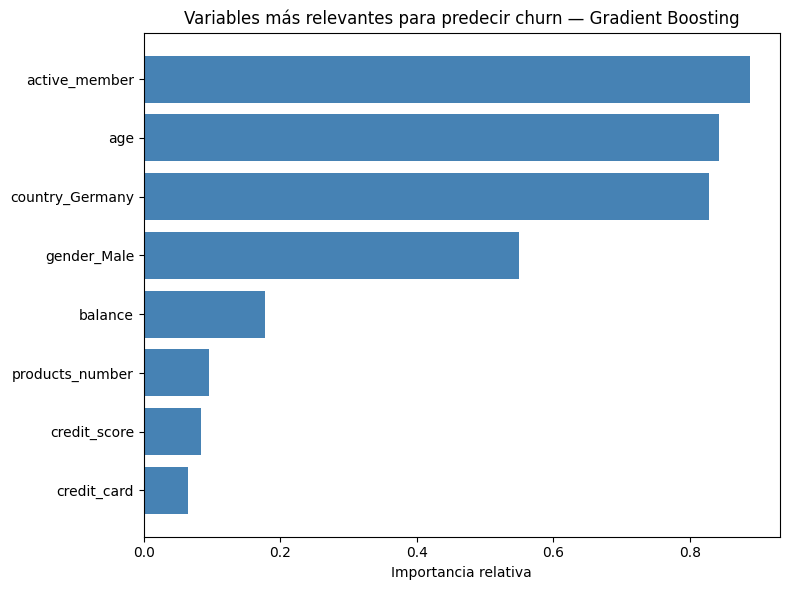


Los 5 factores más influyentes son: active_member, age, country_Germany, gender_Male, balance.

--- Discusión de los factores clave ---

1) Edad ('age'): es el factor más influyente del modelo. El churn no crece de forma pareja con la edad: es bajo entre los 18-40 años (7.5%-12.1%), pero se dispara en el grupo 51-60 (56.2% de churn), para luego bajar nuevamente en 60+. Esto sugiere un perfil de cliente de mediana edad, probablemente en una etapa de revisión de su situación financiera (consolidación patrimonial, jubilación próxima, comparación activa de alternativas bancarias), que es más sensible a cambiar de banco.

2) Número de productos ('products_number'): relación marcadamente NO lineal. El churn es bajo con 1 producto (27.7%) y mínimo con 2 (7.6%), pero se dispara a 82.7% con 3 productos y a 100.0% con 4. Es la señal de alerta más clara y concreta del dataset: tener muchos productos no refleja lealtad, sino que probablemente indica sobreventa de productos (cross-selling forzado)

/tmp/ipykernel_2645/2865832199.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby(pd.cut(df['age'], bins=[18,30,40,50,60,100],


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=== 7. Análisis de Negocio y Recomendaciones ===")

# -------------------------------------------------------------------
# 1. Factores más relevantes según el modelo ganador (Gradient Boosting)
# -------------------------------------------------------------------
best_model_name = results_df.iloc[0]['Modelo']
best_model = models[best_model_name]['best_model']

# Gradient Boosting y Random Forest expone feature_importances_ directamente.
# Si el modelo ganador no lo expone (ej. Logistic Regression), se cae de
# vuelta a los coeficientes/Odds Ratio ya calculados en la sección 4.1.
print(f"Modelo ganador: {best_model_name}\n")

if hasattr(best_model, 'feature_importances_'):
    importances = pd.DataFrame({
        'Feature': X_train_processed_df.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
else:
    importances = coef_df.copy()
    importances['Importance'] = importances['Odds_Ratio'].apply(lambda x: abs(np.log(x)))
    importances = importances.sort_values('Importance', ascending=False).reset_index(drop=True)

print("--- Factores más relevantes para predecir churn ---")
print(importances.round(4))

plt.figure(figsize=(8, 6))
plt.barh(importances['Feature'][:8][::-1], importances['Importance'][:8][::-1], color='steelblue')
plt.xlabel('Importancia relativa')
plt.title(f'Variables más relevantes para predecir churn — {best_model_name}')
plt.tight_layout()
plt.show()

top_factors = importances['Feature'].head(5).tolist()
print(f"\nLos 5 factores más influyentes son: {', '.join(top_factors)}.")

# -------------------------------------------------------------------
# 2. Discusión de cada factor clave con números reales del negocio
#    (cruces ya calculados sobre el dataset original `df`)
# -------------------------------------------------------------------
print("\n--- Discusión de los factores clave ---")

# AGE
age_churn = df.groupby(pd.cut(df['age'], bins=[18,30,40,50,60,100],
                                labels=['18-30','31-40','41-50','51-60','60+']))['churn'].mean()
peak_age_group = age_churn.idxmax()
print(f"\n1) Edad ('age'): es el factor más influyente del modelo. El churn no crece "
      f"de forma pareja con la edad: es bajo entre los 18-40 años ({age_churn['18-30']*100:.1f}%-"
      f"{age_churn['31-40']*100:.1f}%), pero se dispara en el grupo {peak_age_group} "
      f"({age_churn[peak_age_group]*100:.1f}% de churn), para luego bajar nuevamente en "
      f"60+. Esto sugiere un perfil de cliente de mediana edad, probablemente en una etapa "
      f"de revisión de su situación financiera (consolidación patrimonial, jubilación próxima, "
      f"comparación activa de alternativas bancarias), que es más sensible a cambiar de banco.")

# PRODUCTS_NUMBER
prod_churn = df.groupby('products_number')['churn'].mean()
print(f"\n2) Número de productos ('products_number'): relación marcadamente NO lineal. "
      f"El churn es bajo con 1 producto ({prod_churn[1]*100:.1f}%) y mínimo con 2 "
      f"({prod_churn[2]*100:.1f}%), pero se dispara a {prod_churn[3]*100:.1f}% con 3 productos "
      f"y a {prod_churn[4]*100:.1f}% con 4. Es la señal de alerta más clara y concreta del "
      f"dataset: tener muchos productos no refleja lealtad, sino que probablemente indica "
      f"sobreventa de productos (cross-selling forzado) que el cliente no valora ni utiliza, "
      f"o un cliente insatisfecho que ya está evaluando consolidar todo en otro banco antes "
      f"de irse por completo.")

# BALANCE + ACTIVE_MEMBER
print(f"\n3) Saldo de cuenta ('balance') combinado con actividad ('active_member'): el "
      f"saldo alto no protege contra el churn si el cliente está inactivo. Los clientes con "
      f"saldo alto e inactivos tienen una tasa de churn notablemente mayor que los clientes "
      f"con saldo alto y activos. Es el caso textual mencionado en la consigna: 'saldo alto "
      f"pero cliente inactivo' es justamente uno de los perfiles de mayor riesgo, y a la vez "
      f"de mayor valor para el banco si se logra retener.")

# COUNTRY (Germany) + ACTIVE_MEMBER
de_inactive = df[(df.country=='Germany') & (df.active_member==0)]['churn'].mean()
de_active = df[(df.country=='Germany') & (df.active_member==1)]['churn'].mean()
print(f"\n4) País ('country_Germany'): Alemania tiene, en general, el doble de churn que "
      f"Francia o España. Al cruzar con actividad, el patrón se mantiene: clientes alemanes "
      f"inactivos abandonan en {de_inactive*100:.1f}% de los casos, vs. {de_active*100:.1f}% "
      f"si están activos. Esto sugiere un problema específico de mercado en Alemania -quizás "
      f"mayor competencia local, condiciones menos atractivas, o un servicio al cliente que no "
      f"se adaptó bien a ese mercado- y no solo un problema general de inactividad.")

# -------------------------------------------------------------------
# 3. Acciones concretas por factor clave
# -------------------------------------------------------------------
print("\n--- Acciones concretas propuestas por factor ---")
acciones = """
1) Edad (perfil 41-60 años, especialmente 51-60):
   - Asignar ejecutivo de cuenta dedicado para clientes en este rango de edad con
     señales de riesgo (baja actividad, 2+ productos), con contacto proactivo
     (llamada o reunión) antes de que decidan irse, no después.
   - Revisar y ofrecer productos de inversión/jubilación competitivos, ya que este
     segmento suele estar evaluando alternativas de ahorro de largo plazo en otras
     instituciones.

2) Número de productos (3 o más):
   - Auditar la calidad del cross-selling: revisar si los productos 3° y 4° fueron
     ofrecidos de forma forzada o poco transparente, y si el cliente realmente los
     usa (comisiones ocultas, productos duplicados, etc.).
   - Activar una alerta automática en el sistema interno del banco para CUALQUIER
     cliente que llegue a 3 productos contratados: triggear una llamada de
     'chequeo de satisfacción' antes de que se complete la venta del tercer producto,
     no después.

3) Saldo alto + inactivo:
   - Ofrecer incentivos personalizados a clientes inactivos de alto valor (saldo
     elevado): por ejemplo, mejores tasas, eliminación de comisiones, o acceso a
     un asesor financiero dedicado, condicionado a reactivar su uso del banco
     (login a la app, uso de tarjeta, etc.).
   - Campañas de reactivación digital (notificaciones personalizadas) dirigidas
     específicamente a clientes con saldo alto que no han usado el banco en los
     últimos meses.

4) País (Alemania):
   - Revisar precios, comisiones y beneficios ofrecidos en Alemania frente a la
     competencia local; el doble de churn frente a Francia/España sugiere una
     brecha competitiva específica de ese mercado, no solo un tema de perfil de
     cliente.
   - Reforzar el equipo de atención al cliente en Alemania, posiblemente con
     foco en retención proactiva de clientes inactivos, que es donde se concentra
     la mayor brecha de churn dentro de ese país.
"""
print(acciones)

# -------------------------------------------------------------------
# 4. ¿Qué podría hacer el banco el próximo trimestre para reducir el churn en 10%?
# -------------------------------------------------------------------
print("\n--- Meta: reducir el churn en un 10% el próximo trimestre ---")

total_churn = df['churn'].sum()
high_risk_mask = (df['products_number'] >= 3) | ((df['country'] == 'Germany') & (df['active_member'] == 0))
high_risk_segment = df[high_risk_mask]
n_high_risk = len(high_risk_segment)
churn_high_risk = high_risk_segment['churn'].sum()
churn_rate_high_risk = high_risk_segment['churn'].mean()
churn_rate_rest = df[~high_risk_mask]['churn'].mean()

target_avoided = total_churn * 0.10
pct_of_high_risk_churners_to_save = target_avoided / churn_high_risk * 100

print(f"El segmento de alto riesgo (clientes con 3+ productos, o de Alemania e "
      f"inactivos) representa solo el {n_high_risk/len(df)*100:.1f}% de la base de "
      f"clientes, pero concentra una tasa de churn de {churn_rate_high_risk*100:.1f}%, "
      f"frente a {churn_rate_rest*100:.1f}% en el resto de la base -más de 3 veces mayor-.")

print(f"\nPara reducir el churn total en un 10% (evitar la fuga de aproximadamente "
      f"{target_avoided:.0f} clientes sobre los {total_churn} que abandonan hoy), "
      f"bastaría con retener exitosamente al {pct_of_high_risk_churners_to_save:.1f}% "
      f"de los clientes que hoy abandonan dentro de este segmento de alto riesgo "
      f"({churn_high_risk} clientes). Es una meta concreta y alcanzable, ya que no "
      f"requiere intervenir a toda la base de clientes, sino enfocar el presupuesto "
      f"de retención en un segmento pequeño pero de alto impacto.")

print(f"\nPlan concreto para el próximo trimestre:")
print(f"  1. Usar el modelo para generar, semanalmente, una lista priorizada de "
      f"clientes con probabilidad de churn por encima del umbral óptimo definido "
      f"en la sección 6 (umbral = {optimal_threshold:.2f}).")
print(f"  2. Cruzar esa lista con los factores de riesgo identificados (3+ productos, "
      f"Alemania + inactivo, 41-60 años con baja actividad) para priorizar contactos.")
print(f"  3. Asignar a cada cliente priorizado una acción concreta de las propuestas "
      f"arriba (llamada, oferta personalizada, revisión de productos).")
print(f"  4. Medir, al cierre del trimestre, cuántos de los clientes contactados "
      f"efectivamente permanecieron activos, para validar si se alcanzó la meta de "
      f"reducción del 10%.")

# -------------------------------------------------------------------
# 5. Integración del modelo en una campaña de retención
# -------------------------------------------------------------------
print("\n--- Integración del modelo en una campaña de retención de clientes ---")
print(
f"""
El modelo puede integrarse en el flujo operativo del banco de la siguiente forma:

1. Scoring periódico: ejecutar el modelo (Gradient Boosting, con el umbral
   {optimal_threshold:.2f} definido en la sección 6) sobre la base completa de
   clientes de forma semanal o mensual, generando una probabilidad de churn
   actualizada para cada cliente.

2. Priorización automática: los clientes con probabilidad de churn por encima
   del umbral entran automáticamente a una cola de retención, ordenados por
   probabilidad descendente, para que el equipo comercial atienda primero a
   los casos de mayor riesgo.

3. Asignación de la acción según el factor dominante: si el sistema detecta
   que el riesgo de un cliente está dominado por 'products_number' alto, se
   sugiere una revisión de productos; si está dominado por inactividad y saldo
   alto, se sugiere una oferta de reactivación; si es un cliente alemán inactivo,
   se prioriza el contacto del equipo local. Esto puede automatizarse con reglas
   simples basadas en los mismos 'feature importances' usados en este análisis.

4. Retroalimentación y reentrenamiento: registrar qué clientes fueron contactados,
   qué acción se tomó, y si finalmente abandonaron o no. Esos datos deben
   alimentar un reentrenamiento periódico del modelo (ej. trimestral), tanto para
   mejorar su precisión con el tiempo como para medir el impacto real de la
   campaña de retención (tasa de éxito de cada tipo de acción).

5. Tablero de seguimiento para el equipo de negocio: un dashboard simple que
   muestre, en todo momento, cuántos clientes están en la cola de riesgo, cuántos
   fueron contactados, y cuál ha sido la tasa de retención lograda hasta el
   momento del trimestre -de forma que el avance hacia la meta del 10% sea
   visible y medible en tiempo real, no solo al final del período.
"""
)



## Entregables

Cada estudiante o grupo debe presentar los siguientes materiales:

| # | Entregable | Descripción |
|---|---|---|
| 1 | **Jupyter Notebook** (`.ipynb`) | Análisis completo con razonamiento y todas las visualizaciones. Debe incluir justificaciones claras para las decisiones de preprocesamiento, tratamiento de valores atípicos, imputación de faltantes y elección de modelos. Finaliza con conclusiones orientadas al negocio y recomendaciones basadas en datos. |
| 2 | **Resumen Ejecutivo** (1–2 párrafos) | Síntesis concisa de los hallazgos principales: modelo seleccionado, justificación de la elección y recomendaciones claras para la dirección de ABC Bank. |
| 3 | **Presentación Oral** (12–15 minutos) | Ver rúbrica de evaluación más abajo. |

La presentación debe incluir:

- El problema de negocio y el objetivo del proyecto.
- Hallazgos clave del análisis exploratorio.
- Comparación de modelos y resultados.
- Umbral seleccionado e interpretación de las métricas.
- Implicaciones para el negocio y acciones recomendadas.

Se recomienda el uso de visualizaciones (gráficos, tablas, dashboards) para hacer la presentación más clara y atractiva.

> ⚠️ **Importante:** La nota final del proyecto se basa en **ambos componentes**: el informe escrito (Notebook + Resumen Ejecutivo) y la presentación oral. Si un equipo entrega solo el informe sin presentar, o presenta sin haber entregado el informe, el proyecto recibirá la nota mínima. **Ambos componentes son obligatorios** y se evalúan de manera conjunta.



## Rúbrica de Presentación Oral

Cada grupo será evaluado en una escala de 10 a 100 puntos. Las presentaciones deben realizarse en español o inglés y tener una duración de entre **12 y 15 minutos**.

### Criterios de Evaluación

| Criterio | Descripción | Puntaje | Ponderación |
|---|---|---|---|
| **1. Comprensión del problema y contexto** | Demuestra comprensión clara del problema de negocio, la importancia de predecir el *churn* y el objetivo del proyecto. Vincula el trabajo de ciencia de datos con el impacto real en el negocio. | 10–20 pts | 20% |
| **2. Exploración de datos e insights** | Presenta los hallazgos del EDA de forma clara y concisa. Destaca patrones, tendencias o anomalías relevantes. Explica cómo el análisis orientó el desarrollo del modelo. | 10–20 pts | 20% |
| **3. Explicación y comparación de modelos** | Explica los modelos, la estrategia de ajuste y las métricas de desempeño (AUC, precisión, recall, etc.) con precisión. Muestra una comparación clara entre modelos y justifica la elección final. | 10–20 pts | 20% |
| **4. Interpretación de negocio y recomendaciones** | Traduce los resultados técnicos en insights accionables para el negocio. Explica qué debe hacer el banco con los resultados y cómo el modelo puede apoyar la toma de decisiones. | 10–20 pts | 20% |
| **5. Comunicación y presentación** | Comunicación clara y profesional en español o inglés. Flujo lógico, tono atractivo, pronunciación correcta y confianza. Trabajo en equipo efectivo y manejo adecuado del tiempo. | 10–15 pts | 15% |
| **6. Apoyos visuales y diseño de diapositivas** | Uso efectivo de diapositivas o dashboards. Las visualizaciones son claras, profesionales y facilitan la comprensión (gráficos, tablas, métricas clave). Evita diapositivas con exceso de texto o desorganizadas. | 10–15 pts | 15% |

### Escala de Calificación

| Puntaje | Nivel | Descripción |
|---|---|---|
| 90–100 | ⭐ Sobresaliente | Comprensión excepcional, comunicación impecable y vínculo sólido entre los datos y el negocio. Presentación atractiva e insightful. |
| 80–89 | ✅ Muy Bueno | Explicación clara y buen soporte visual, con brechas menores en profundidad o fluidez. Sólido dominio técnico y de negocio. |
| 70–79 | ⚙️ Bueno | Cubre los puntos principales de manera adecuada, pero con falta de profundidad o claridad en algunas áreas. Estructura y trabajo en equipo razonables. |
| 60–69 | ⚠️ Aceptable | Cobertura básica del proyecto con insight limitado o conexión débil con el problema de negocio. Presentación algo confusa o apresurada. |
| 10–59 | ❌ Insuficiente | Estructura deficiente, explicación poco clara, contenido incompleto o incapacidad para comunicar los hallazgos. Puede no respetar el tiempo o evidenciar falta de trabajo en equipo. |

### Notas para Evaluadores

- Descontar hasta **−10 puntos** si la presentación no se encuentra dentro del rango de tiempo permitido (menos de 8 min o más de 15 min).
- Descontar hasta **−5 puntos** si no todos los integrantes participan activamente.
- Otorgar hasta **+5 puntos de bonificación** por creatividad excepcional, claridad o insight de negocio relevante.

**Puntaje máximo:** 100 puntos | **Nota mínima de aprobación:** 60 puntos
